# Visualising Reskilling Scenarios


### Notebook purpose:
1. Combines the individual simulation outputs to one dataframe.
2. Manipulates the output data for visualisations.
3. Plots all paper graphs.

#### 1. Load and prepare data

!! Important !! Select the specific environment/kernel for this notebook

In [27]:
# PythonProject/Simulating-Re-Skilling-Journeys/.venv/bin/python
# Python 3.11

# This environment runs with a newer numpy version to ensure compatibility with matplotlib and seaborn (required for line plots)

Load necessary requirements and patches

In [1]:
import os
import sys
import logging
import copy
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib as mpl
import matplotlib.pyplot as plt
from src.patches import seaborn_patch  # patch fix to avoid compatibility issues with updated script
import seaborn as sns

from src import utils, plotting_utils, stats_utils
from src import mapping_career_causeways

# OPTIONAL: Load the "autoreload" extension so that code can change
%load_ext autoreload

# OPTIONAL: always reload modules so that as you change code in src, it gets loaded
%autoreload 2

# Settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

sns.set_context("notebook")
# sns.set(rc={'figure.figsize': (16, 9.)})
sns.set_style("ticks")

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 120)
pd.options.display.float_format = "{:,.2f}".format

logging.basicConfig(level=logging.INFO, stream=sys.stdout)

# load paths
useful_paths = utils.UsefulPaths()

from tqdm import tqdm
import pickle
from scipy import stats

from src.modelling.reskilling import ReskillingPathways
rp = ReskillingPathways()

→ Digital URIs: 21 | present in matrix: 21
→ Green   URIs: 570 | present in matrix: 570


##### Define model setting combinations

In [ ]:
year = 2023
job_pools = ["at_risk", "shortage"]  # both flows (was ["at_risk"])
threshold = "viable-isco4d" # ["viable-low", "low", "perc", "emp"]
regional_constraints = ["regC", "no-regC"] # ["regC", "no-regC"]
reskilling_modes = [
    "reskill-digital",
    "reskill-green",
    "reskill-optimal",
    # "reskill-coreWeight",  # not ran
    "reskill-coreRanked"
]

# COEFFY normalization column per job_pool
coeff_pool_mapping = {
    "at_risk": "COEFFY_share_unviable_to_decarbonize",
    "shortage": "COEFFY_share_shortage"
}

# Rename job pool labels for nicer plotting
scenario_mapping = {
    "job_pool": {
        "at_risk": "AR",
        "shortage": "SH"
    }
}

# Income-eligible KEEP list = complement of this DROP list (countries with <20% observed
# earnings). Set UNCONDITIONALLY so the earnings masking in cells 9 & 14 always applies
# (prevents the silent DROP-leak when iso_missing_earnings would otherwise be undefined).
iso_missing_earnings = [
    "IT", "NL", "DE", "HU", "AT", "RO", "PL", "ES", "LT", "CY", "BE", "CZ", "HR", "IS", "LV"
]

# Toggle recomputing the model output
overwrite_model_results = True  # rebuild df_tidy from the NEW-run pickles (was False)

##### Preprocess model outputs

In [ ]:
# -----------------------------------------------------------------------
# Collect raw model output across all options (reg/no-reg) and scenarios
# NEW LAYOUT: reskilling_simulation/<scenario>/<tag>/<tag>.pkl, each pkl = {scenario:{country:df}}
# -----------------------------------------------------------------------
folder_name = "reskilling_simulation"
fmt_string = "{reskilling_mode}_wage-opt_{regional_constraint}_{year}"
output_dir = os.path.join(useful_paths.data_processed, "eulfs", "reskilling_model_results")
fname = "model_data_tidy_{}_{}".format(year, threshold)

if overwrite_model_results:
    # assemble {scenario: {country: df}} per (mode, regC) by reading each scenario's pkl
    data_store = {}
    for reskilling_mode in reskilling_modes:
        for regional_constraint in regional_constraints:
            tag = fmt_string.format(
                reskilling_mode=reskilling_mode,
                regional_constraint=regional_constraint,
                year=year,
            )
            per_scenario = {}
            for job_pool in job_pools:
                fpath = os.path.join(
                    useful_paths.figure_dir, folder_name,
                    job_pool,                      # <-- NEW scenario subfolder
                    tag, "{}.pkl".format(tag),
                )
                per_scenario[job_pool] = pd.read_pickle(fpath)[job_pool]
            data_store[(threshold, reskilling_mode, regional_constraint)] = per_scenario

    # save raw store
    fdir_out = os.path.join(useful_paths.figure_dir, folder_name, "model_data_store.pkl")
    with open(fdir_out, "wb") as handle:
        pickle.dump(data_store, handle, protocol=pickle.HIGHEST_PROTOCOL)

    # -----------------------------------------------------------------------
    # Build aggregated tidy cube across scenarios
    # -----------------------------------------------------------------------
    data_tidy = []
    for model_version in tqdm(list(data_store.keys())):
        sub_dict = data_store[model_version]
        for job_pool in job_pools:
            if job_pool not in sub_dict:
                continue
            df_pool = pd.concat(list(sub_dict[job_pool].values()))
            df_pool = df_pool.assign(
                job_pool=job_pool,
                viability_threshold=model_version[0],
                reskilling_mode=model_version[1],
                regional_constraint=model_version[2],
            )
            data_tidy.append(df_pool)

    df_tidy = pd.concat(data_tidy).reset_index()

    # -----------------------------------------------------------------------
    # Clean
    # -----------------------------------------------------------------------
    df_tidy = df_tidy.replace(scenario_mapping)

    # mask aggregate earnings for income-ineligible countries (DROP list from cell 7)
    df_tidy.loc[
        df_tidy["COUNTRYW"].isin(iso_missing_earnings),
        "earnings_delta_closest_switch_sum_mio",
    ] = np.nan

    df_tidy = pd.merge(df_tidy, rp.nace_labels, on="NACE2_1D", how="left")

    utils.save_df_to_files(df=df_tidy, output_dir=output_dir, fname_no_ext=fname)
else:
    df_tidy = pd.read_pickle(os.path.join(output_dir, fname + ".pkl"))

Further prepare data

In [6]:
#HARDCODED TO ONE TRANSITION FLOW

# only keep reskilling steps 0 to 20?
cols2keep = ~df_tidy.columns.str.contains("step_21") #step_31/21
df_tidy = df_tidy.loc[:, cols2keep]

In [7]:
# reduce data to core sectors
df_tidy = df_tidy.loc[df_tidy["paper_selection"]]

In [8]:
iso_missing_earnings = ['IT', 'NL', 'DE', 'HU', 'AT', 'RO','PL', 'ES', 'LT', 'CY', 'BE','CZ', 'HR', 'IS', 'LV']

In [ ]:
import re
import numpy as np
import pandas as pd

# Assumes:
#   df_tidy  : wide, group-aggregated output from simulate/simulate_regional
#   iso_missing_earnings : list of ISO codes with no earnings (ok if empty/missing)

try:
    iso_missing_earnings
except NameError:
    iso_missing_earnings = []

# ── Explicit regex pickers (no ambiguity) ──────────────────────────────────────
def pick_cols_regex(df, pattern):
    rx = re.compile(pattern)
    return [c for c in df.columns if rx.match(c)]

# transitions (counts)
transitions_cols   = pick_cols_regex(df_tidy, r"^n_viable_transitions_step_\d+$")

# per-observation totals (€)
earnings_cols_abs  = pick_cols_regex(df_tidy, r"^earnings_delta_closest_switch_sum_step_\d+$")

# per-worker (€, unweighted)
earnings_cols_rel  = pick_cols_regex(df_tidy, r"^earnings_delta_closest_switch_step_\d+$")

# per-worker % change
pct_cols           = pick_cols_regex(df_tidy, r"^earnings_delta_closest_switch_pct_step_\d+$")

# optional HV variants
earnings_cols_abs_hv = pick_cols_regex(df_tidy, r"^earnings_delta_closest_switch_sum_hv_step_\d+$")
earnings_cols_rel_hv = pick_cols_regex(df_tidy, r"^earnings_delta_closest_switch_hv_step_\d+$")
pct_cols_hv          = pick_cols_regex(df_tidy, r"^earnings_delta_closest_switch_hv_pct_step_\d+$")

# id_vars = all columns minus value_vars
value_vars_all = set(transitions_cols) | set(earnings_cols_abs) | set(earnings_cols_rel) | set(pct_cols) \
                 | set(earnings_cols_abs_hv) | set(earnings_cols_rel_hv) | set(pct_cols_hv)
index_cols = [c for c in df_tidy.columns if c not in value_vars_all]

# helper to extract the trailing integer step
def extract_step_from_name(s):
    return s.str.extract(r"_step_(\d+)$", expand=False).astype(int)

# ── Mask earnings for countries without earnings ───────────────────────────────
if len(earnings_cols_abs):
    df_tidy.loc[df_tidy["COUNTRYW"].isin(iso_missing_earnings), earnings_cols_abs] = np.nan
if len(earnings_cols_rel):
    df_tidy.loc[df_tidy["COUNTRYW"].isin(iso_missing_earnings), earnings_cols_rel] = np.nan
if len(earnings_cols_abs_hv):
    df_tidy.loc[df_tidy["COUNTRYW"].isin(iso_missing_earnings), earnings_cols_abs_hv] = np.nan
if len(earnings_cols_rel_hv):
    df_tidy.loc[df_tidy["COUNTRYW"].isin(iso_missing_earnings), earnings_cols_rel_hv] = np.nan
# pct series are implied by annual_earnings, so they’ll already be NaN where needed

# ── Melt to long ───────────────────────────────────────────────────────────────
# transitions
df_tidy_long_transitions = df_tidy.melt(
    id_vars=index_cols, value_vars=transitions_cols,
    var_name="colname", value_name="n_transitions"
)
df_tidy_long_transitions["reskilling_step"] = extract_step_from_name(df_tidy_long_transitions["colname"])
df_tidy_long_transitions = df_tidy_long_transitions.drop(columns=["colname"])

# totals (€)
df_tidy_long_earnings_abs = df_tidy.melt(
    id_vars=index_cols, value_vars=earnings_cols_abs,
    var_name="colname", value_name="earnings_delta_abs"
)
df_tidy_long_earnings_abs["reskilling_step"] = extract_step_from_name(df_tidy_long_earnings_abs["colname"])
df_tidy_long_earnings_abs = df_tidy_long_earnings_abs.drop(columns=["colname"])

# per-worker (€, unweighted)
df_tidy_long_earnings_rel = df_tidy.melt(
    id_vars=index_cols, value_vars=earnings_cols_rel,
    var_name="colname", value_name="earnings_delta_rel"
)
df_tidy_long_earnings_rel["reskilling_step"] = extract_step_from_name(df_tidy_long_earnings_rel["colname"])
df_tidy_long_earnings_rel = df_tidy_long_earnings_rel.drop(columns=["colname"])

# per-worker % change (optional)
if len(pct_cols):
    df_tidy_long_earnings_pct = df_tidy.melt(
        id_vars=index_cols, value_vars=pct_cols,
        var_name="colname", value_name="earnings_delta_pct"
    )
    df_tidy_long_earnings_pct["reskilling_step"] = extract_step_from_name(df_tidy_long_earnings_pct["colname"])
    df_tidy_long_earnings_pct = df_tidy_long_earnings_pct.drop(columns=["colname"])
else:
    df_tidy_long_earnings_pct = None

# optional helpers
def melt_optional(df, cols, value_name):
    if not len(cols):
        return None
    out = df.melt(id_vars=index_cols, value_vars=cols, var_name="colname", value_name=value_name)
    out["reskilling_step"] = extract_step_from_name(out["colname"])
    return out.drop(columns=["colname"])

df_tidy_long_earnings_abs_hv = melt_optional(df_tidy, earnings_cols_abs_hv, "earnings_delta_abs_hv")
df_tidy_long_earnings_rel_hv = melt_optional(df_tidy, earnings_cols_rel_hv, "earnings_delta_rel_hv")
df_tidy_long_earnings_pct_hv = melt_optional(df_tidy, pct_cols_hv,          "earnings_delta_pct_hv")

# ── Merge per-worker & totals ─────────────────────────────────────────────────
keys_merge = ["COUNTRYW","NUTS_ID","NACE2_1D_label","regional_constraint","job_pool","reskilling_mode","reskilling_step"]

earnings_abs = df_tidy_long_earnings_abs[keys_merge + ["earnings_delta_abs"]]
earnings_rel = df_tidy_long_earnings_rel[keys_merge + ["earnings_delta_rel"]]

df_tidy_long_earnings_merged = pd.merge(
    earnings_abs, earnings_rel, on=keys_merge, how="left", validate="m:1"
)

if df_tidy_long_earnings_pct is not None:
    df_tidy_long_earnings_merged = df_tidy_long_earnings_merged.merge(
        df_tidy_long_earnings_pct[keys_merge + ["earnings_delta_pct"]],
        on=keys_merge, how="left", validate="m:1"
    )

# ── Scales ────────────────────────────────────────────────────────────────────
df_tidy_long_earnings_merged["earnings_delta_abs_mio"] = df_tidy_long_earnings_merged["earnings_delta_abs"] / 1e6
df_tidy_long_earnings_merged["earnings_delta_abs_bio"] = df_tidy_long_earnings_merged["earnings_delta_abs"] / 1e9
df_tidy_long_earnings_merged["earnings_delta_rel_mio"] = df_tidy_long_earnings_merged.get("earnings_delta_rel") / 1e6
df_tidy_long_earnings_merged["earnings_delta_rel_bio"] = df_tidy_long_earnings_merged.get("earnings_delta_rel") / 1e9

# ── Weighted per-worker (ties exactly to totals) ──────────────────────────────
cand_weight_cols = [c for c in [
    "COEFFY_share_unviable_to_decarbonize",
    "COEFFY_share_high_carbon",
    "COEFFY_share_shortage",
] if c in df_tidy.columns]

if not cand_weight_cols:
    raise ValueError("No COEFFY_share_* weight columns found in df_tidy.")

if len(cand_weight_cols) > 1:
    jp_vals = set(df_tidy.get("job_pool", pd.Series(dtype=object)).dropna().unique().tolist())
    if {"AR","at_risk"} & jp_vals:
        weight_col = "COEFFY_share_unviable_to_decarbonize"
    elif {"HC","high_carbon"} & jp_vals:
        weight_col = "COEFFY_share_high_carbon"
    elif {"SH","shortage"} & jp_vals:
        weight_col = "COEFFY_share_shortage"
    else:
        totals = {c: df_tidy[c].sum(skipna=True) for c in cand_weight_cols}
        weight_col = max(totals, key=totals.get)
else:
    weight_col = cand_weight_cols[0]

keys_no_step = ["COUNTRYW","NUTS_ID","NACE2_1D_label","regional_constraint","job_pool","reskilling_mode"]
wide_weights = (
    df_tidy[keys_no_step + [weight_col]]
    .drop_duplicates()
    .rename(columns={weight_col: "weight_sum"})
)

df_tidy_long_earnings_merged = df_tidy_long_earnings_merged.merge(
    wide_weights, on=keys_no_step, how="left", validate="m:1"
)

df_tidy_long_earnings_merged["earnings_delta_rel_w"] = (
    df_tidy_long_earnings_merged["earnings_delta_abs"] / df_tidy_long_earnings_merged["weight_sum"]
)
z = df_tidy_long_earnings_merged["weight_sum"] == 0
df_tidy_long_earnings_merged.loc[z, "earnings_delta_rel_w"] = np.nan

df_tidy_long_earnings_merged["earnings_delta_rel_w_mio"] = df_tidy_long_earnings_merged["earnings_delta_rel_w"] / 1e6
df_tidy_long_earnings_merged["earnings_delta_rel_w_bio"] = df_tidy_long_earnings_merged["earnings_delta_rel_w"] / 1e9

# (Optional) add HV series into the same tidy frame
for opt_df, val in [(df_tidy_long_earnings_abs_hv, "earnings_delta_abs_hv"),
                    (df_tidy_long_earnings_rel_hv, "earnings_delta_rel_hv"),
                    (df_tidy_long_earnings_pct_hv, "earnings_delta_pct_hv")]:
    if opt_df is not None:
        df_tidy_long_earnings_merged = df_tidy_long_earnings_merged.merge(
            opt_df[keys_merge + [val]], on=keys_merge, how="left", validate="m:1"
        )

print("Detected columns:")
print("  transitions :", len(transitions_cols))
print("  totals(€)   :", len(earnings_cols_abs))
print("  per-worker  :", len(earnings_cols_rel))
print("  pct         :", len(pct_cols))
print("  HV totals   :", len(earnings_cols_abs_hv))
print("  HV per-w    :", len(earnings_cols_rel_hv))
print("  HV pct      :", len(pct_cols_hv))
print("Data prep complete. Result:", df_tidy_long_earnings_merged.shape)

# ============================================================================
# SWITCHER-BASED INCOME (ported from revision/income_report.py) — ADDITIVE.
# Keeps earnings_delta_rel/_rel_w; adds per-cell switcher columns + a common-step
# aggregate (income_common) so Fig R3 and the income LaTeX table share ONE
# definition: switcher-only, at-risk-weighted (model _sum/_delta weight), KEEP-list.
# ============================================================================
_KEEP = sorted(set(df_tidy["COUNTRYW"].unique()) - set(iso_missing_earnings))
_JL_FLOW = {"AR": 20, "SH": 30, "at_risk": 20, "shortage": 30}

def _wmean_sw(v, w):
    v = np.asarray(v, float); w = np.asarray(w, float)
    m = ~np.isnan(v) & ~np.isnan(w)
    return np.average(v[m], weights=w[m]) if m.any() and w[m].sum() > 0 else np.nan

def _atrisk_weight(sub, last):
    """At-risk population per cell = median_step(sum_step/delta_step); fallback COEFFY*share."""
    co = sub["COEFFY"].to_numpy(float); ratios = []
    for s in range(last + 1):
        de = sub.get(f"earnings_delta_closest_switch_step_{s}")
        su = sub.get(f"earnings_delta_closest_switch_sum_step_{s}")
        if de is None or su is None:
            continue
        de = de.to_numpy(float); su = su.to_numpy(float)
        with np.errstate(divide="ignore", invalid="ignore"):
            ratios.append(np.where(np.abs(de) > 1e-9, su / de, np.nan))
    with np.errstate(invalid="ignore"):
        Wc = np.nanmedian(np.vstack(ratios), axis=0) if ratios else np.full(len(sub), np.nan)
        share = np.nanmedian(Wc / co) if np.isfinite(Wc).any() else np.nan
    return np.where(np.isnan(Wc), co * share, Wc)

def compute_income_switcher_common(reg="regC"):
    """Common-step switcher income, at-risk-weighted, KEEP-only -> tidy aggregate.
    SINGLE source for Fig R3 AND the income LaTeX table (identical by construction)."""
    rec = []
    for jp in df_tidy["job_pool"].unique():
        last = _JL_FLOW.get(jp, 30)
        for mode in df_tidy["reskilling_mode"].unique():
            sub = df_tidy[(df_tidy["regional_constraint"] == reg)
                          & (df_tidy["reskilling_mode"] == mode)
                          & (df_tidy["job_pool"] == jp)
                          & (df_tidy["COUNTRYW"].isin(_KEEP))]
            if not len(sub):
                continue
            Wc = _atrisk_weight(sub, last)
            base = sub["annual_earnings"].to_numpy(float) if "annual_earnings" in sub else np.full(len(sub), np.nan)
            for s in range(last + 1):
                vc = f"transition_viable_step_{s}"; pc = f"earnings_delta_closest_switch_pct_step_{s}"
                ec = f"earnings_delta_closest_switch_step_{s}"
                if vc not in sub.columns or pc not in sub.columns:
                    continue
                vi = np.nan_to_num(sub[vc].astype(float).to_numpy(), nan=0) > 0.5
                rec.append(dict(
                    job_pool=jp, reskilling_mode=mode, reskilling_step=s,
                    switcher_pct=_wmean_sw(sub[pc].to_numpy(float)[vi], Wc[vi]) * 100,
                    switcher_eur=_wmean_sw(sub[ec].to_numpy(float)[vi], Wc[vi]) if ec in sub.columns else np.nan,
                    base_eur=_wmean_sw(base[vi], Wc[vi]),
                    n_switch_w=float(np.nansum(Wc[vi])),
                ))
    return pd.DataFrame.from_records(rec)

income_common = compute_income_switcher_common(reg="regC")

# per-cell switcher columns on the merged frame (additive; old columns untouched)
_tr = df_tidy_long_transitions[keys_merge + ["n_transitions"]].drop_duplicates(keys_merge)
df_tidy_long_earnings_merged = df_tidy_long_earnings_merged.merge(_tr, on=keys_merge, how="left", validate="m:1")
df_tidy_long_earnings_merged["is_switcher"] = df_tidy_long_earnings_merged["n_transitions"].fillna(0) >= 1
if "earnings_delta_pct" in df_tidy_long_earnings_merged.columns:
    df_tidy_long_earnings_merged["earnings_switcher_pct"] = (
        df_tidy_long_earnings_merged["earnings_delta_pct"].where(df_tidy_long_earnings_merged["is_switcher"]) * 100.0)
df_tidy_long_earnings_merged["earnings_switcher_eur"] = (
    df_tidy_long_earnings_merged["earnings_delta_rel"].where(df_tidy_long_earnings_merged["is_switcher"]))
if "annual_earnings" in df_tidy_long_earnings_merged.columns:
    df_tidy_long_earnings_merged["earnings_switcher_base"] = (
        df_tidy_long_earnings_merged["annual_earnings"].where(df_tidy_long_earnings_merged["is_switcher"]))

print("Switcher income ready: income_common", income_common.shape,
      "| per-cell cols added: is_switcher, earnings_switcher_pct/_eur/_base")
print("Fig R3 plots income_common (at-risk-weighted aggregate) = the income table, by construction.")

def compute_income_switcher_by(group_col, reg="regC"):
    """Switcher income grouped by an extra dimension (NACE2_1D_label sector, or COUNTRYW),
    at-risk-weighted within switchers, KEEP-only — SAME population/weighting as income_common,
    so grouped figs A3/A4 tie to R3 and the table. Returns per (group, job_pool, reskilling_mode,
    reskilling_step): switcher_pct, switcher_eur, n_switch_w."""
    rec = []
    for jp in df_tidy["job_pool"].unique():
        last = _JL_FLOW.get(jp, 30)
        for mode in df_tidy["reskilling_mode"].unique():
            sub = df_tidy[(df_tidy["regional_constraint"] == reg)
                          & (df_tidy["reskilling_mode"] == mode)
                          & (df_tidy["job_pool"] == jp)
                          & (df_tidy["COUNTRYW"].isin(_KEEP))].reset_index(drop=True)
            if not len(sub):
                continue
            Wc = _atrisk_weight(sub, last)
            g = sub[group_col].astype(str).to_numpy()
            for s in range(last + 1):
                vc = f"transition_viable_step_{s}"; pc = f"earnings_delta_closest_switch_pct_step_{s}"
                ec = f"earnings_delta_closest_switch_step_{s}"
                if vc not in sub.columns or pc not in sub.columns:
                    continue
                vi = np.nan_to_num(sub[vc].astype(float).to_numpy(), nan=0) > 0.5
                pct = sub[pc].to_numpy(float)
                eur = sub[ec].to_numpy(float) if ec in sub.columns else np.full(len(sub), np.nan)
                for gv in pd.unique(g):
                    sel = vi & (g == gv)
                    if not sel.any():
                        continue
                    rec.append(dict(group=gv, job_pool=jp, reskilling_mode=mode, reskilling_step=s,
                                    switcher_pct=_wmean_sw(pct[sel], Wc[sel]) * 100,
                                    switcher_eur=_wmean_sw(eur[sel], Wc[sel]),
                                    n_switch_w=float(np.nansum(Wc[sel]))))
    return pd.DataFrame.from_records(rec)
print("grouped switcher aggregate ready: compute_income_switcher_by('NACE2_1D_label'|'COUNTRYW')")

Data inspection

In [10]:
earnings_rel.describe()

,reskilling_step,earnings_delta_rel
count,"282,240.00","95,424.00"
mean,10.00,"-16,987.32"
std,6.06,"18,273.84"
min,0.00,"-82,860.00"
25%,5.00,"-28,167.28"
50%,10.00,"-16,732.24"
75%,15.00,"-3,662.18"
max,20.00,"57,463.67"


In [9]:
import numpy as np
import pandas as pd

def _fmt(x):
    try:
        return f"{x:,.2f}"
    except Exception:
        return x

print("Detected job_pool values:", sorted(df_tidy_long_earnings_merged["job_pool"].dropna().unique().tolist()))
steps_abs = sorted(df_tidy_long_earnings_merged["reskilling_step"].dropna().unique().tolist())
print("Steps present:", steps_abs[:10], "...", steps_abs[-3:] if len(steps_abs)>10 else steps_abs)

print("\nEarnings (totals, €) — describe():")
print(df_tidy_long_earnings_merged["earnings_delta_abs"].describe().apply(_fmt))

if "earnings_delta_rel" in df_tidy_long_earnings_merged:
    print("\nEarnings (per-worker, unweighted €, ‘typical worker’) — describe():")
    print(df_tidy_long_earnings_merged["earnings_delta_rel"].describe().apply(_fmt))

print("\nEarnings (per-worker, weighted by headcount €, ties to totals) — describe():")
print(df_tidy_long_earnings_merged["earnings_delta_rel_w"].describe().apply(_fmt))

# Masking check (only among missing-earnings countries)
if 'iso_missing_earnings' in globals() and len(iso_missing_earnings) > 0:
    mask_c = df_tidy_long_earnings_merged["COUNTRYW"].isin(iso_missing_earnings)
    na_abs_share = df_tidy_long_earnings_merged.loc[mask_c, "earnings_delta_abs"].isna().mean()
    if "earnings_delta_rel" in df_tidy_long_earnings_merged:
        na_rel_share = df_tidy_long_earnings_merged.loc[mask_c, "earnings_delta_rel"].isna().mean()
    else:
        na_rel_share = float("nan")
    print(f"\nMasking among missing-earnings countries: abs NaN share={na_abs_share:.3f}, rel NaN share={na_rel_share:.3f}")

# Reconciliation: totals ≡ weighted_mean × weight_sum
chk = df_tidy_long_earnings_merged.dropna(subset=["earnings_delta_abs","earnings_delta_rel_w","weight_sum"]).copy()
chk.loc[:, "recon_err"] = chk["earnings_delta_abs"] - chk["earnings_delta_rel_w"]*chk["weight_sum"]
print("\nReconciliation (totals - weighted_mean × weight_sum):")
if len(chk):
    print("  MAE =", _fmt(chk["recon_err"].abs().mean()),
          "| max|err| =", _fmt(chk["recon_err"].abs().max()))
    print("\nWorst 5 reconciliation rows:")
    cols_show = ["COUNTRYW","NUTS_ID","NACE2_1D_label","regional_constraint","job_pool",
                 "reskilling_mode","reskilling_step",
                 "earnings_delta_abs","weight_sum","earnings_delta_rel_w","recon_err"]
    display(chk.loc[chk["recon_err"].abs().sort_values(ascending=False).index[:5], cols_show])
else:
    print("  (no rows to check)")

# Weighted vs unweighted per-worker gap (only if unweighted exists)
if "earnings_delta_rel" in df_tidy_long_earnings_merged:
    diff_pw = df_tidy_long_earnings_merged.dropna(subset=["earnings_delta_rel","earnings_delta_rel_w"]).copy()
    diff_pw.loc[:, "per_worker_gap"] = diff_pw["earnings_delta_rel_w"] - diff_pw["earnings_delta_rel"]
    print("\n(per-worker weighted - per-worker unweighted) — describe():")
    print(diff_pw["per_worker_gap"].describe().apply(_fmt))
    print("\nWorst 5 gaps (headcount weighting vs typical-worker):")
    cols_show2 = ["COUNTRYW","NUTS_ID","NACE2_1D_label","regional_constraint","job_pool",
                  "reskilling_mode","reskilling_step",
                  "earnings_delta_rel","earnings_delta_rel_w","weight_sum","per_worker_gap"]
    display(diff_pw.loc[diff_pw["per_worker_gap"].abs().sort_values(ascending=False).index[:5], cols_show2])
else:
    print("\n(no unweighted per-worker series present — this is fine if you prefer to use weighted only)")

panel = (
    df_tidy_long_earnings_merged
    .groupby(["job_pool","regional_constraint","reskilling_mode","reskilling_step"], dropna=False)
    .agg(
        totals_eur      = ("earnings_delta_abs", "sum"),
        mean_unweighted = ("earnings_delta_rel", "mean") if "earnings_delta_rel" in df_tidy_long_earnings_merged else ("earnings_delta_rel_w", lambda x: np.nan),
        mean_weighted   = ("earnings_delta_rel_w", "mean"),
        weight_sum      = ("weight_sum", "sum")
    )
    .reset_index()
)
print("\nStep-level panel summary (first 10 rows):")
display(panel.head(10))

print("Debug checks completed.")


Detected job_pool values: ['SH']
Steps present: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] ... [28, 29, 30]

Earnings (totals, €) — describe():
count           93,248.00
mean         8,033,148.85
std         50,409,944.98
min        -11,660,026.63
25%                  0.00
50%                  0.00
75%                  0.00
max      1,726,538,844.04
Name: earnings_delta_abs, dtype: object

Earnings (per-worker, unweighted €, ‘typical worker’) — describe():
count     93,135.00
mean       1,755.41
std        6,412.31
min      -21,216.37
25%            0.00
50%            0.00
75%            0.00
max       72,639.53
Name: earnings_delta_rel, dtype: object

Earnings (per-worker, weighted by headcount €, ties to totals) — describe():
count    93,124.00
mean         56.09
std         205.46
min        -684.40
25%           0.00
50%           0.00
75%           0.00
max       2,343.21
Name: earnings_delta_rel_w, dtype: object

Masking among missing-earnings countries: abs NaN share=1.000, rel NaN share=1

,COUNTRYW,NUTS_ID,NACE2_1D_label,regional_constraint,job_pool,reskilling_mode,reskilling_step,earnings_delta_abs,weight_sum,earnings_delta_rel_w,recon_err
299110,FR,FR10,Wholesale and Retail Trade; Repair of Motor Ve...,no-regC,SH,reskill-optimal,29,"941,950,324.58","1,343,881.00",700.92,-0.00
297856,FR,FR10,Wholesale and Retail Trade; Repair of Motor Ve...,regC,SH,reskill-optimal,29,"941,950,324.58","1,343,881.00",700.92,-0.00
289034,FR,FR10,Wholesale and Retail Trade; Repair of Motor Ve...,no-regC,SH,reskill-optimal,28,"941,950,324.58","1,343,881.00",700.92,-0.00
309186,FR,FR10,Wholesale and Retail Trade; Repair of Motor Ve...,no-regC,SH,reskill-optimal,30,"941,950,324.58","1,343,881.00",700.92,-0.00
287780,FR,FR10,Wholesale and Retail Trade; Repair of Motor Ve...,regC,SH,reskill-optimal,28,"941,950,324.58","1,343,881.00",700.92,-0.00



(per-worker weighted - per-worker unweighted) — describe():
count     93,011.00
mean      -1,701.03
std        6,210.99
min      -70,296.32
25%            0.00
50%            0.00
75%            0.00
max       20,531.97
Name: per_worker_gap, dtype: object

Worst 5 gaps (headcount weighting vs typical-worker):


,COUNTRYW,NUTS_ID,NACE2_1D_label,regional_constraint,job_pool,reskilling_mode,reskilling_step,earnings_delta_rel,earnings_delta_rel_w,weight_sum,per_worker_gap
312056,LU,LU00,"Agriculture, Forestry and Fishing",no-regC,SH,reskill-coreRanked,30,"72,639.53","2,343.21","2,418.00","-70,296.32"
312059,LU,LU00,Construction,no-regC,SH,reskill-coreRanked,30,"63,727.96","1,791.44","3,224.00","-61,936.52"
312060,LU,LU00,Wholesale and Retail Trade; Repair of Motor Ve...,no-regC,SH,reskill-coreRanked,30,"61,048.67","1,930.62","73,408.00","-59,118.05"
311197,CH,CH03,"Agriculture, Forestry and Fishing",no-regC,SH,reskill-coreRanked,30,"60,734.87","1,959.19","5,208.00","-58,775.68"
309958,CH,CH03,"Agriculture, Forestry and Fishing",regC,SH,reskill-coreRanked,30,"60,734.87","1,959.19","5,208.00","-58,775.68"



Step-level panel summary (first 10 rows):


,job_pool,regional_constraint,reskilling_mode,reskilling_step,totals_eur,mean_unweighted,mean_weighted,weight_sum
0,SH,no-regC,reskill-coreRanked,0,0.00,0.00,0.00,"240,639,515.00"
1,SH,no-regC,reskill-coreRanked,1,0.00,0.00,0.00,"240,639,515.00"
2,SH,no-regC,reskill-coreRanked,2,0.00,0.00,0.00,"240,639,515.00"
3,SH,no-regC,reskill-coreRanked,3,0.00,0.00,0.00,"240,639,515.00"
4,SH,no-regC,reskill-coreRanked,4,0.00,0.00,0.00,"240,639,515.00"
5,SH,no-regC,reskill-coreRanked,5,0.00,0.00,0.00,"240,639,515.00"
6,SH,no-regC,reskill-coreRanked,6,0.00,0.00,0.00,"240,639,515.00"
7,SH,no-regC,reskill-coreRanked,7,0.00,0.00,0.00,"240,639,515.00"
8,SH,no-regC,reskill-coreRanked,8,0.00,0.00,0.00,"240,639,515.00"
9,SH,no-regC,reskill-coreRanked,9,0.00,0.00,0.00,"240,639,515.00"


Debug checks completed.


#### 2. Plotting parameters for aggregated reskilling journeys and income changes

In [16]:
# ===============================
# PRE-DEFINITIONS
# ===============================

from statannotations.Annotator import Annotator
import numpy as np

# --- earnings metrics to plot
#   'totals_mio'            -> uses df_tidy_long_earnings_merged['earnings_delta_abs_mio'] (M€)
#   'per_worker_unweighted' -> uses df_tidy_long_earnings_merged['earnings_delta_rel'] (€), i.e. typical cell
#   'per_worker_weighted'   -> uses df_tidy_long_earnings_merged['earnings_delta_rel_w'] (€), headcount-weighted
EARNINGS_VARIANT = "per_worker_unweighted"

EARNINGS_VALUE_COL = {
    "totals_mio": "earnings_delta_abs_mio",
    "per_worker_unweighted": "earnings_delta_rel",
    "per_worker_weighted": "earnings_delta_rel_w",
}[EARNINGS_VARIANT]

# Verify if column exists
if (EARNINGS_VARIANT == "per_worker_weighted"
    and EARNINGS_VALUE_COL not in df_tidy_long_earnings_merged.columns):
    raise ValueError(
        "EARNINGS_VARIANT='per_worker_weighted' selected, "
        "but 'earnings_delta_rel_w' is not present. "
        "Compute/merge it before plotting."
    )

# --- Job-pool selection with aliases
JOB_POOL_ALIASES = {
    "at_risk": ["AR", "at_risk"],
    "shortage": ["SH", "shortage"],
}
job_pool = "at_risk"  # ['at_risk', 'shortage']
job_pool_values = JOB_POOL_ALIASES.get(job_pool, [job_pool])

# --- Step order using transitions long
reskilling_steps = sorted(df_tidy_long_transitions["reskilling_step"].unique())
order = reskilling_steps

# --- Mode orders
_present_modes = set(df_tidy_long_transitions["reskilling_mode"].unique())
hue_order_main    = [m for m in ["reskill-optimal", "reskill-coreRanked", "reskill-digital", "reskill-green"] if m in _present_modes]
hue_order_digital = [m for m in ["reskill-optimal", "reskill-digital"] if m in _present_modes]
hue_order_green   = [m for m in ["reskill-optimal", "reskill-green"]   if m in _present_modes]

# --- Pairwise comparisons for statannotations per step
def build_pairs(steps, modes):
    modes = [m for m in modes if m in _present_modes]
    pairs = []
    for s in steps:
        for i in range(len(modes)):
            for j in range(i + 1, len(modes)):
                pairs.append(((s, modes[i]), (s, modes[j])))
    return pairs

pairs = build_pairs(order, modes=hue_order_main)

# --- Stats/plot tunables
alpha = 0.001
test = "Kruskal"
comparisons_correction = "Benjamini-Hochberg"
text_format = "star"
loc = "outside"
show_test_name = False
verbose = False

palette = "BrBG_r"
figsize = (6, 4)

# Seaborn 0.12+: estimator must be a callable
errorbar = ("ci", 99)       # bootstrap CI level
n_boot = 1000               # bootstrap samples
estimator = np.median       # median estimator
seed = 42
draw_kde_plots = False

# --- Axis labels/units, adapted to metric
xlabel = "Reskilling journey step"
ylabel_transitions = "Unlocked job transitions (-)"

YLABELS = {
    "totals_mio": r"$\Delta$ Annual income (M€)",
    "per_worker_unweighted": r"$\Delta$ Annual income per worker (€) — typical cell",
    "per_worker_weighted": r"$\Delta$ Annual income per worker (€) — headcount weighted",
}
ylabel_earnings = YLABELS[EARNINGS_VARIANT]

# annotate units to the top of y-axis (optional, if you add a small annotation)
yax_title_transitions = "#"
yax_title_earnings    = "€" if "per_worker" in EARNINGS_VARIANT else "€m"
yax_title_earnings_mio = "€m"
yax_title_earnings_bio = "€bn"
yax_title_scaling_transitions = 1.01
yax_title_scaling_earnings    = 1.05

# --- Output dir (unchanged)
results_dir = os.path.join(
    useful_paths.figure_dir,
    folder_name.format(threshold=threshold)
)

In [ ]:
# ---------------------------------------------------------------------------
# Shared canvas + fonts for the SIX single-axis line panels (R1/A1/A2 transitions
# + R3/A3/A4 income): identical figsize, margins AND font sizes so all render
# uniformly and stay legible after the document scales the 6x4in canvas down to
# ~0.49\textwidth (~3.2-3.5in -> scale ~0.53-0.59). No tight_layout / bbox_inches.
# ---------------------------------------------------------------------------
import matplotlib as mpl

# Ticks at 13pt (the priority element) -> ~6.9-7.7pt on page. Axis TITLES at 12pt:
# y-titles were shortened (e.g. "Income change (%)") so axis TITLES match ticks at 13pt.
# Legend 10pt + compact so the 21-entry country legend stays inside the axes.
LINE_PANEL_RC = {
    "font.size": 13,
    "axes.titlesize": 13, "axes.labelsize": 13,   # titles match ticks (y-titles shortened)
    "xtick.labelsize": 13, "ytick.labelsize": 13,
    "legend.fontsize": 10, "legend.title_fontsize": 10,
    "legend.handlelength": 1.1, "legend.handletextpad": 0.4,
    "legend.columnspacing": 0.7, "legend.labelspacing": 0.25, "legend.borderpad": 0.3,
}
plt.rcParams.update(LINE_PANEL_RC)

LINE_PANEL_FIGSIZE = (6, 4)
# Wider left for the 13pt EUR y-ticks; lower top so the tall rotated y-title fits;
# identical for all six so the saved canvas stays uniform.
LINE_PANEL_MARGINS = dict(left=0.25, right=0.975, top=0.94, bottom=0.16)

def new_line_panel(figsize=LINE_PANEL_FIGSIZE):
    """Standard single-axis line-panel figure (shared figsize + fonts; margins fixed at save)."""
    plt.rcParams.update(LINE_PANEL_RC)   # re-assert in case a later cell changed rc
    fig, ax = plt.subplots(figsize=figsize)
    return fig, ax

def save_line_panel(fig, path):
    """Apply the shared margins and save with canvas == figsize (no tight bbox/pad)."""
    fig.subplots_adjust(**LINE_PANEL_MARGINS)
    fig.savefig(path, format="pdf")
    plt.close(fig)


In [17]:
# --- Shared axis: intensity --- #
SCENARIO_XMAX = {"at_risk": 20, "shortage": 30}
SCENARIO_YMAX = {"at_risk": 10, "shortage": 5}

def detect_scenario(df):
    ALIASES = {"at_risk": {"AR","at_risk"}, "shortage": {"SH","shortage"}}
    pools_present = set(df["job_pool"].unique())
    return "shortage" if (pools_present & ALIASES["shortage"]) else "at_risk"

def set_axes_uniform(ax, scenario, step_max_data):
    xmax = max(int(step_max_data), SCENARIO_XMAX[scenario])
    ymax = SCENARIO_YMAX[scenario]
    ax.set_xlim(-0.5, xmax)
    ax.set_ylim(0, ymax)
    ax.set_xticks(np.arange(0, xmax + 1, 5), minor=False)
    ax.set_xticks(np.arange(0, xmax + 1, 1),  minor=True)
    ax.set_yticks(np.arange(0, ymax + 1, 1), minor=False)
    ax.set_yticks(np.arange(0, ymax + 1, 1), minor=True)
    return xmax, ymax

In [18]:
# --- Shared axis: income --- #

SCENARIO_YLIMS = {
    "at_risk": (-3200, 1600),
    "shortage": (0, 1600),   # start at 0; avoids showing “−0”
}

def euro_fmt_no_neg_zero(x, _):
    # avoid printing "−0"
    if abs(x) < 1e-9:
        x = 0.0
    return f"€{x:,.0f}".replace(",", " ")

def set_earnings_axes(ax, scenario: str, step_max_data: int, x_default: int):
    """
    Sets x/y axes consistently for earnings plots:
    - x: max(data extent, scenario default)
    - y: fixed per scenario using SCENARIO_YLIMS
    - ticks: 5 on x; majors every 800 on y, minors every 400
    """
    from matplotlib.ticker import MultipleLocator, AutoMinorLocator, FuncFormatter

    xmax = max(int(step_max_data), int(x_default))
    ax.set_xlim(-0.5, xmax)
    ax.xaxis.set_major_locator(MultipleLocator(5))
    ax.xaxis.set_minor_locator(MultipleLocator(1))

    y0, y1 = SCENARIO_YLIMS[scenario]
    ax.set_ylim(y0, y1)
    ax.yaxis.set_major_locator(MultipleLocator(800))
    ax.yaxis.set_minor_locator(MultipleLocator(400))
    ax.yaxis.set_major_formatter(FuncFormatter(euro_fmt_no_neg_zero))

    # reference line at €0 if it's inside the range
    if y0 <= 0 <= y1:
        ax.axhline(0, linestyle="--", color="black", linewidth=0.6, zorder=0)

    return xmax, (y0, y1)

#### 3. Main visualisations for the paper

In [12]:
print(df_tidy_long_transitions["reskilling_mode"].unique())
df_tidy_long_transitions

['reskill-digital' 'reskill-green' 'reskill-optimal' 'reskill-coreRanked']


,COUNTRYW,NUTS_ID,NACE2_1D,COEFFY,AGE,NOBS,COEFFY_share_low_carbon,COEFFY_share_neutral,COEFFY_share_viable_to_decarbonize,COEFFY_share_unviable_to_decarbonize,COEFFY_share_high_carbon,annual_earnings,COEFFY_share_shortage,n_viable_transitions_sum_step_0,transition_viable_step_0,n_viable_transitions_sum_step_1,transition_viable_step_1,n_viable_transitions_sum_step_2,transition_viable_step_2,n_viable_transitions_sum_step_3,transition_viable_step_3,n_viable_transitions_sum_step_4,transition_viable_step_4,n_viable_transitions_sum_step_5,transition_viable_step_5,n_viable_transitions_sum_step_6,transition_viable_step_6,n_viable_transitions_sum_step_7,transition_viable_step_7,n_viable_transitions_sum_step_8,transition_viable_step_8,n_viable_transitions_sum_step_9,transition_viable_step_9,n_viable_transitions_sum_step_10,transition_viable_step_10,n_viable_transitions_sum_step_11,transition_viable_step_11,n_viable_transitions_sum_step_12,transition_viable_step_12,n_viable_transitions_sum_step_13,transition_viable_step_13,n_viable_transitions_sum_step_14,transition_viable_step_14,n_viable_transitions_sum_step_15,transition_viable_step_15,n_viable_transitions_sum_step_16,transition_viable_step_16,n_viable_transitions_sum_step_17,transition_viable_step_17,n_viable_transitions_sum_step_18,transition_viable_step_18,n_viable_transitions_sum_step_19,transition_viable_step_19,n_viable_transitions_sum_step_20,transition_viable_step_20,n_viable_transitions_sum_step_22,transition_viable_step_22,n_viable_transitions_sum_step_23,transition_viable_step_23,n_viable_transitions_sum_step_24,...,added_skill_label_step_2,added_skill_idx_step_3,added_skill_label_step_3,added_skill_idx_step_4,added_skill_label_step_4,added_skill_idx_step_5,added_skill_label_step_5,added_skill_idx_step_6,added_skill_label_step_6,added_skill_idx_step_7,added_skill_label_step_7,added_skill_idx_step_8,added_skill_label_step_8,added_skill_idx_step_9,added_skill_label_step_9,added_skill_idx_step_10,added_skill_label_step_10,added_skill_idx_step_11,added_skill_label_step_11,added_skill_idx_step_12,added_skill_label_step_12,added_skill_idx_step_13,added_skill_label_step_13,added_skill_idx_step_14,added_skill_label_step_14,added_skill_idx_step_15,added_skill_label_step_15,added_skill_idx_step_16,added_skill_label_step_16,added_skill_idx_step_17,added_skill_label_step_17,added_skill_idx_step_18,added_skill_label_step_18,added_skill_idx_step_19,added_skill_label_step_19,added_skill_idx_step_20,added_skill_label_step_20,added_skill_idx_step_22,added_skill_label_step_22,added_skill_idx_step_23,added_skill_label_step_23,added_skill_idx_step_24,added_skill_label_step_24,added_skill_idx_step_25,added_skill_label_step_25,added_skill_idx_step_26,added_skill_label_step_26,added_skill_idx_step_27,added_skill_label_step_27,added_skill_idx_step_28,added_skill_label_step_28,added_skill_idx_step_29,added_skill_label_step_29,added_skill_idx_step_30,added_skill_label_step_30,NACE2_1D_label,NACE2_1D_label_short,paper_selection,n_transitions,reskilling_step
0,AT,AT11,A,"2,139.31",40.00,124.00,0.00,"2,002.02",0.00,137.29,137.29,NaN,"2,170.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Agriculture, Forestry and Fishing","Agri., Forest., Fish.",True,0.00,0
1,AT,AT11,C,"28,282.23",41.91,"1,333.00",0.00,"26,501.35",76.31,"1,704.57","1,780.88",NaN,"28,923.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,Na

##### Fig R 1: Transition numbers for program comparison with regional constraints

In [ ]:
# ==============================
# Reskilling journeys - regC (3 modes)  +  "first unlocked job" markers
# ==============================

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

reg_constraint = "regC"

# Fallbacks so the block runs standalone
figsize = (6, 4) if "figsize" not in globals() else figsize
ylabel_transitions = "Unlocked transitions (–)"
xlabel = "Reskilling journey step"

# --- Detect scenario (at_risk vs shortage) from the loaded long df ---
ALIASES = {"at_risk": {"AR", "at_risk"}, "shortage": {"SH", "shortage"}}
pools_present = set(df_tidy_long_transitions["job_pool"].unique())
if pools_present & ALIASES["shortage"]:
    scenario = "shortage"
    x_target_max, y_target_max = 30, 5
else:
    scenario = "at_risk"
    x_target_max, y_target_max = 20, 10

# --- Filter to regC + scenario ---
pool_filter = df_tidy_long_transitions["job_pool"].isin(ALIASES[scenario])
data = df_tidy_long_transitions.loc[
    (df_tidy_long_transitions["regional_constraint"] == reg_constraint) & pool_filter,
    ["reskilling_step", "n_transitions", "reskilling_mode"]
].copy()

# Clean numeric & drop bad rows
data["reskilling_step"] = pd.to_numeric(data["reskilling_step"], errors="coerce")
data["n_transitions"]   = pd.to_numeric(data["n_transitions"],   errors="coerce")
data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(subset=["reskilling_step", "n_transitions"], inplace=True)
data["reskilling_step"] = data["reskilling_step"].astype(int)

# --- Choose which modes to show ---
modes_present = set(data["reskilling_mode"].unique())
def first_present(cands):
    for c in cands:
        if c in modes_present:
            return c
    return None

mode_opt  = first_present(["reskill-optimal"])
mode_core = first_present(["reskill-coreRanked"])
target_candidates = ["reskill-green", "reskill-digital"] if scenario == "shortage" else ["reskill-digital", "reskill-green"]
mode_target = first_present(target_candidates)

modes_to_plot = [m for m in [mode_opt, mode_core, mode_target] if m is not None]
if not modes_to_plot:
    raise ValueError(f"No expected reskilling modes found. Saw: {sorted(modes_present)}")

label_map = {
    "reskill-optimal":    "Tailored",
    "reskill-coreWeight": "Transferable",
    "reskill-coreRanked": "Transferable",
    "reskill-digital":    "Digital",
    "reskill-green":      "Green",
}
data = data.loc[data["reskilling_mode"].isin(modes_to_plot)].copy()
data["mode_label"] = data["reskilling_mode"].map(label_map)

# --- Palette per display label (subset to labels actually present) ---
base_palette = {
    "Tailored":     "cornflowerblue",
    "Transferable": "grey",
    "Digital":      "mediumaquamarine",  # used for at_risk
    "Green":        "seagreen",          # used for shortage
}
labels_present = list(dict.fromkeys(data["mode_label"]))  # preserve order
palette_display = {k: base_palette[k] for k in labels_present if k in base_palette}

# --- Plot ---
fig, ax = new_line_panel()

# Match the sector plot look: light grey panel + white grid
ax.set_facecolor("#f2f2f2")
fig.patch.set_facecolor("white")
ax.grid(True, which="major", color="white", linewidth=1)
ax.grid(True, which="minor", color="white", linewidth=0.5)
ax.set_axisbelow(True)

# Main lines
sns.lineplot(
    data=data,
    x="reskilling_step",
    y="n_transitions",
    hue="mode_label",
    hue_order=labels_present,
    dashes=True,
    markers=True,
    estimator="median",   # aggregate per step within seaborn
    ci="sd",
    n_boot=1000,          # ignored with ci='sd', harmless
    palette=palette_display,
    seed=42,
    ax=ax,
    legend="brief",
)

# Axes
scenario = detect_scenario(df_tidy_long_transitions)

# Axes (uniform per scenario)
step_max_data = data["reskilling_step"].max() if len(data) else SCENARIO_XMAX[scenario]
xmax, ymax = set_axes_uniform(ax, scenario, step_max_data)

# Reference line at 1 (kept)
ax.axhline(1, linestyle="--", color="black", linewidth=0.5, zorder=0)

ax.set_ylabel(ylabel_transitions)
ax.set_xlabel(xlabel)
sns.despine()

# =========================
# Compute first crossing (median ≥ 1) per mode_label
# =========================
med = (
    data.groupby(["mode_label", "reskilling_step"])["n_transitions"]
        .median()
        .reset_index()
        .sort_values(["mode_label", "reskilling_step"])
)

crossings = {}
for mode in labels_present:
    m = med.loc[med["mode_label"] == mode]
    # earliest step with median >= 1
    cand = m.loc[m["n_transitions"] >= 1]
    if cand.empty:
        continue
    s_star = int(cand["reskilling_step"].iloc[0])
    y_star = float(m.loc[m["reskilling_step"] == s_star, "n_transitions"].iloc[0])
    crossings[mode] = (s_star, y_star)

# =========================
# Draw vertical red dashed line (from y=0 to y=y_star) + a red triangle at (s_star, y_star)
# =========================
for mode, (s_star, y_star) in crossings.items():
    # vertical segment up to the actual aggregated value
    ax.vlines(
        s_star, 0, y_star,
        linestyles="--", colors="red", linewidth=1.2, zorder=1, alpha=0.9
    )
    # triangle marker pointing *up* placed exactly on the line value
    ax.plot(
        s_star, y_star,
        marker=(3, 0, 0),  # upward triangle
        markersize=10,
        markerfacecolor="red",
        markeredgecolor="none",
        zorder=3,
    )

# =========================
# Legend (add custom item + white background box)
# =========================
# Build a custom handle for the crossing marker
cross_handle = Line2D(
    [], [], linestyle="--", color="red", linewidth=1.2,
    marker=(3, 0, 0), markersize=8, markerfacecolor="red", markeredgecolor="none",
    label="First unlocked job transition",
)

# Grab the existing legend (created by seaborn), then append our handle
leg = ax.legend(
    handles=[*ax.get_legend_handles_labels()[0], cross_handle],
    labels=[*ax.get_legend_handles_labels()[1], "First unlocked job transition"],
    loc="upper left",
    frameon=True, fancybox=True, framealpha=0.95,
)
# Style the legend box to be white (so lines behind don't show through)
leg.get_frame().set_facecolor("white")
leg.get_frame().set_edgecolor("white")
leg.get_frame().set_linewidth(0)

# Save (PDF for LaTeX)
out_dir = os.path.join(results_dir)
utils.ccdir(out_dir)
outfile = os.path.join(out_dir, f"{scenario}_n_transitions_by_mode_{reg_constraint}.pdf")
save_line_panel(fig, outfile)
plt.close(fig)
print(f"Saved: {outfile}")

In [29]:
# ---- Add occupation label back into the long earnings frame ----
# Pick the best available occupation column from the wide df_tidy
occ_candidates = [c for c in [
    "orig_ISCO08_3D_label", "ISCO08_3D_label", "preferredLabel",
    "orig_ISCO08_3D", "ISCO08_3D"
] if c in df_tidy.columns]
if not occ_candidates:
    raise KeyError("No occupation column available in df_tidy to carry into long frames.")

# Build a lookup keyed by the same no-step keys you already use
keys_no_step = ["COUNTRYW","NUTS_ID","NACE2_1D_label","regional_constraint","job_pool","reskilling_mode"]
lookup_occ = (df_tidy[keys_no_step + [occ_candidates[0]]]
              .dropna(subset=[occ_candidates[0]])
              .drop_duplicates()
              .rename(columns={occ_candidates[0]: "occ_label"}))

# Merge the occupation label into the long earnings frame
df_tidy_long_earnings_merged = df_tidy_long_earnings_merged.merge(
    lookup_occ, on=keys_no_step, how="left", validate="m:1"
)

# (Optional) also add it to the long transitions frame, so both sides align
if "occ_label" not in df_tidy_long_transitions.columns:
    df_tidy_long_transitions = df_tidy_long_transitions.merge(
        lookup_occ, on=keys_no_step, how="left", validate="m:1"
    )

In [30]:
# ==============================
# Shortage (inward) — fastest source occupations to first low-carbon unlock
# ==============================
import os
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D

# ----- controls
POOL  = "shortage"           # inward flow into low-carbon jobs
REGC  = "regC"
N_TOP = 10                   # show 10 occupations
modes_want = ["reskill-optimal","reskill-coreRanked"]  # (Tailored, Transferable)

label_map = {
    "reskill-optimal":    "Tailored",
    "reskill-coreRanked": "Transferable",
    "reskill-green":      "Green",
}
ALIASES = {"at_risk": {"AR","at_risk"}, "shortage": {"SH","shortage"}}

def euro0(x):
    return "—" if pd.isna(x) else "€{:,.0f}".format(x).replace(",", " ")

# -----------------------------
# A) first-unlock steps
# -----------------------------
tran = df_tidy_long_transitions.loc[
    (df_tidy_long_transitions["regional_constraint"] == REGC) &
    (df_tidy_long_transitions["reskilling_mode"].isin(modes_want)) &
    (df_tidy_long_transitions["job_pool"].astype(str).isin(ALIASES[POOL])),
    ["COUNTRYW","occ_label","reskilling_mode","reskilling_step","n_transitions"]
].copy()

tran["reskilling_step"] = pd.to_numeric(tran["reskilling_step"], errors="coerce").astype("Int64")
tran["n_transitions"]   = pd.to_numeric(tran["n_transitions"],   errors="coerce")
tran.dropna(subset=["occ_label","reskilling_step","n_transitions"], inplace=True)
tran["reskilling_step"] = tran["reskilling_step"].astype(int)

# median transitions per (occ, country, mode, step)
g = (tran.groupby(["occ_label","COUNTRYW","reskilling_mode","reskilling_step"])["n_transitions"]
         .median().reset_index())

def first_hit_step(df):
    df = df.sort_values("reskilling_step")
    hit = df.loc[df["n_transitions"] >= 1, "reskilling_step"]
    return int(hit.iloc[0]) if len(hit) else np.nan

first_by_cty = (g.groupby(["occ_label","COUNTRYW","reskilling_mode"])
                  .apply(first_hit_step, include_groups=False)
                  .rename("first_step_cty").reset_index())

# how many countries unlock + global fastest step (by country minima)
n_ctrs = (first_by_cty.dropna(subset=["first_step_cty"])
                    .groupby(["occ_label","reskilling_mode"])["COUNTRYW"]
                    .nunique().rename("n_countries").reset_index())
min_step = (first_by_cty.groupby(["occ_label","reskilling_mode"])["first_step_cty"]
                      .min().rename("first_step").reset_index())

first_global = n_ctrs.merge(min_step, on=["occ_label","reskilling_mode"], how="outer")
first_global["mode_label"] = first_global["reskilling_mode"].map(label_map)

# pick fastest occupations across ANY mode (union), then keep those for both modes
best_any_mode = (
    first_global.dropna(subset=["first_step"])
                .sort_values(["first_step","n_countries"], ascending=[True, False])
                .groupby("occ_label", as_index=False)
                .agg(first_step=("first_step","min"),
                     n_countries=("n_countries","max"))
)
base  = best_any_mode.head(N_TOP)[["occ_label"]]
order = base["occ_label"].tolist()
plot_df = first_global[first_global["occ_label"].isin(order)].copy()

# -----------------------------
# B) €/worker at country-specific first step (median across countries)
# -----------------------------
earn = df_tidy_long_earnings_merged.loc[
    (df_tidy_long_earnings_merged["regional_constraint"] == REGC) &
    (df_tidy_long_earnings_merged["reskilling_mode"].isin(modes_want)) &
    (df_tidy_long_earnings_merged["job_pool"].astype(str).isin(ALIASES[POOL])),
    ["COUNTRYW","occ_label","reskilling_mode","reskilling_step","earnings_delta_rel_w"]
].copy()

earn["reskilling_step"]      = pd.to_numeric(earn["reskilling_step"], errors="coerce").astype("Int64")
earn["earnings_delta_rel_w"] = pd.to_numeric(earn["earnings_delta_rel_w"], errors="coerce")
earn.dropna(subset=["occ_label","reskilling_step"], inplace=True)
earn["reskilling_step"] = earn["reskilling_step"].astype(int)

earn_at_first = (
    earn.merge(first_by_cty, on=["COUNTRYW","occ_label","reskilling_mode"], how="inner", validate="m:1")
        .loc[lambda d: d["reskilling_step"] == d["first_step_cty"]]
        .groupby(["occ_label","reskilling_mode"])["earnings_delta_rel_w"]
        .median().rename("earn_pw_at_first").reset_index()
)

plot_df = plot_df.merge(earn_at_first, on=["occ_label","reskilling_mode"], how="left")
plot_df["mode_label"] = plot_df["reskilling_mode"].map(label_map)
plot_df["occ_label"]  = pd.Categorical(plot_df["occ_label"], categories=order, ordered=True)
plot_df.sort_values(["occ_label","mode_label"], inplace=True)

# -----------------------------
# C) plot — match your at-risk look
# -----------------------------
# exact palette used elsewhere
palette = {"Tailored":"cornflowerblue", "Transferable":"grey", "Green":"seagreen"}
SHADE_ALPHA = 0.30

# Sort occupations by the shortest reskilling step (ascending)
order = (
    plot_df.groupby("occ_label")["first_step"]
    .min()
    .sort_values(ascending=True)
    .index.tolist()
)
plot_df["occ_label"] = pd.Categorical(plot_df["occ_label"], categories=order, ordered=True)
plot_df.sort_values(["occ_label","mode_label"], inplace=True)

# figure sizing (similar density to your 6x4 but grows with N_TOP)
fig_w = 10
fig_h = 4 + 0.28*max(5, len(order))
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

# light panel + white grid, like your other charts
ax.set_facecolor("#f2f2f2")
fig.patch.set_facecolor("white")
ax.grid(True, axis="x", color="white", linewidth=1)
ax.grid(True, which="minor", axis="x", color="white", linewidth=0.5)
ax.set_axisbelow(True)

# only show Tailored & Transferable in legend
modes_present = [m for m in ["Tailored","Transferable"] if m in plot_df["mode_label"].unique()]
n_series = len(modes_present)
bar_h = 0.8 / max(n_series,1)
offsets = np.linspace(-(n_series-1)/2, (n_series-1)/2, n_series) * bar_h

y_positions = np.arange(len(order))
xmax = float(np.nanmax(plot_df["first_step"])) if len(plot_df) else 30

for j, mode_lbl in enumerate(modes_present):
    sub = plot_df[plot_df["mode_label"] == mode_lbl]
    y = pd.Index(order).get_indexer(sub["occ_label"])
    ax.barh(
        y + offsets[j],
        sub["first_step"],
        height=bar_h,
        color=palette.get(mode_lbl, "steelblue"),
        alpha=SHADE_ALPHA,
        label=mode_lbl,
        linewidth=1.0
    )

# y labels
ax.set_yticks(y_positions)
ax.set_yticklabels(order)
ax.invert_yaxis()

# x axis: ticks every 5
ax.set_xlabel("Reskilling journey steps to first unlocked job transition")
ax.set_xlim(0, xmax + 6)
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.xaxis.set_minor_locator(MultipleLocator(1))

# get existing legend items first (just after plotting the bars)
handles, labels = ax.get_legend_handles_labels()

# add a text-only (invisible) item as an explanatory note
note_handle = Line2D([], [], linestyle="None", marker=None)
handles.append(note_handle)
labels.append("Average €/worker change annually")

leg = ax.legend(
    handles, labels,
    loc="upper left",
    bbox_to_anchor=(0.0, 1.02),
    borderaxespad=0.0,
    ncol=len(handles),
    frameon=True,
    framealpha=0.95,
)
leg.get_frame().set_facecolor("white")
leg.get_frame().set_linewidth(0)
plt.tight_layout(rect=[0, 0, 1, 0.92])

for i, occ in enumerate(order):
    row = (plot_df[plot_df["occ_label"] == occ]
               .sort_values(["first_step","n_countries"], ascending=[True, False])
               .iloc[0])
    txt = f"{euro0(row['earn_pw_at_first'])}"
    ax.text(xmax + 0.5, i, txt, va="center", ha="left", fontsize=9, color="black")

sns.despine(left=False, bottom=False)

# save (same pattern as your other charts)
out_dir = os.path.join(results_dir)
utils.ccdir(out_dir)
outfile = os.path.join(out_dir, f"{POOL}_fastest_occ_with_earnings_{REGC}.pdf")
plt.savefig(outfile, bbox_inches="tight", format="pdf")
plt.close(fig)
print(f"Saved: {outfile}")

Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/figures/reskilling_simulation/shortage_fastest_occ_with_earnings_regC.pdf


/var/folders/1w/t9ryrq_57m77f4wzbw78745m044mx9/T/ipykernel_56091/1749104013.py:111: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_df.groupby("occ_label")["first_step"]


##### Fig A 1: Transition numbers for tailored scenario, by sectors

In [ ]:
# ==============================
# Optimal reskilling journeys by sector — regC +  "first unlocked job" markers
# ==============================

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

only_regC = True
reg_constraint = "regC"
figsize = (6, 4)
x_col, y_col = "reskilling_step", "n_transitions"
ylabel_transitions = "Unlocked transitions (–)"
xlabel = "Reskilling journey step"

# Scenario detection (for axis ranges)
ALIASES = {"at_risk": {"AR", "at_risk"}, "shortage": {"SH", "shortage"}}
pools_present = set(df_tidy_long_transitions["job_pool"].unique())
scenario = "shortage" if (pools_present & ALIASES["shortage"]) else "at_risk"

# Sector label column
sector_col = "NACE2_1D_label_short" if "NACE2_1D_label_short" in df_tidy_long_transitions.columns else "NACE2_1D_label"

# --- Filter: reskill-optimal only (+ regC if requested) ---
filt = (df_tidy_long_transitions["reskilling_mode"] == "reskill-optimal")
if only_regC:
    filt &= (df_tidy_long_transitions["regional_constraint"] == reg_constraint)

data = df_tidy_long_transitions.loc[filt, [x_col, y_col, sector_col]].copy()

# Clean numeric
data[x_col] = pd.to_numeric(data[x_col], errors="coerce")
data[y_col] = pd.to_numeric(data[y_col], errors="coerce")
data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(subset=[x_col, y_col], inplace=True)
data[x_col] = data[x_col].astype(int)

# Optional: keep top-K sectors to declutter legend
top_k = None  # e.g., 12
if top_k:
    med_tmp = data.groupby(sector_col)[y_col].median().sort_values(ascending=False)
    keep = set(med_tmp.head(top_k).index)
    data = data[data[sector_col].isin(keep)]

# Compute median per sector per step (so we can style markers individually)
med = (
    data.groupby([sector_col, x_col])[y_col]
        .median()
        .reset_index()
        .sort_values([sector_col, x_col])
)

# Palette per sector (Blues)
unique_sectors = list(med[sector_col].dropna().unique())
palette = sns.color_palette("Blues", n_colors=len(unique_sectors))
palette_dict = dict(zip(unique_sectors, palette))

# Axes ranges by scenario (but honor data extent)
step_max_data = int(med[x_col].max()) if len(med) else (30 if scenario == "shortage" else 20)
x_target_max = 30 if scenario == "shortage" else 20
y_target_max = 5  if scenario == "shortage" else 10
xmax = max(step_max_data, x_target_max)
ymax = y_target_max

# Plot
fig, ax = new_line_panel()

# Match the main plot look
ax.set_facecolor("#f2f2f2")
fig.patch.set_facecolor("white")
ax.grid(True, which="major", color="white", linewidth=1)
ax.grid(True, which="minor", color="white", linewidth=0.5)
ax.set_axisbelow(True)

scenario = detect_scenario(df_tidy_long_transitions)
step_max_data = med[x_col].max() if len(med) else SCENARIO_XMAX[scenario]
xmax, ymax = set_axes_uniform(ax, scenario, step_max_data)

# Reference line + labels (kept)
ax.axhline(1, linestyle="--", color="black", linewidth=0.5, zorder=1)
ax.set_ylabel(ylabel_transitions)
ax.set_xlabel(xlabel)

# Draw each sector line (dashed) + small markers; then overlay ONE red triangle at first crossing
for sec in unique_sectors:
    df_sec = med[med[sector_col] == sec]
    xs = df_sec[x_col].to_numpy()
    ys = df_sec[y_col].to_numpy()
    col = palette_dict[sec]

    # main line with small circular markers (matching line color)
    ax.plot(
        xs, ys,
        label=sec,
        color=col,
        linestyle="--",
        linewidth=1.2,
        marker="o",
        markersize=3,
        markerfacecolor=col,
        markeredgecolor="none",
        zorder=2,
    )

    # find the first step where median >= 1
    ge1 = np.where(ys >= 1)[0]
    if ge1.size:
        i0 = int(ge1[0])
        sx, sy = xs[i0], ys[i0]
        # overlay red upward triangle (no edge) ONLY at the crossing point
        ax.plot(
            sx, sy,
            marker=(3, 0, 0),          # upward triangle
            markersize=9,
            markerfacecolor="red",
            markeredgecolor="none",
            linestyle="None",
            zorder=3,
        )

# Axes
ax.set_xlim(-0.5, xmax)
ax.set_ylim(0, ymax)  # start at 0 to align with main plot convention
ax.set_xticks(np.arange(0, xmax + 1, 5), minor=False)
ax.set_xticks(np.arange(0, xmax + 1, 1), minor=True)
ax.set_yticks(np.arange(0, ymax + 1, 1), minor=False)
ax.set_yticks(np.arange(0, ymax + 1, 1), minor=True)

# Reference line at y=1
ax.axhline(1, linestyle="--", color="black", linewidth=0.5, zorder=1)

ax.set_ylabel(ylabel_transitions)
ax.set_xlabel(xlabel)

# Legend (white background, smaller font) + add custom red marker entry
# Build custom handle for "first unlocked job transition"
cross_handle = Line2D(
    [], [], linestyle="None",
    marker=(3, 0, 0), markersize=8, markerfacecolor="red", markeredgecolor="none",
    label="First unlocked job transition",
)

# Get current handles/labels (sector lines), append custom marker handle
handles, labels = ax.get_legend_handles_labels()
handles.append(cross_handle)
labels.append("First unlocked job transition")

leg = ax.legend(
    handles, labels,
    title="Sector",
    loc="upper left",
    frameon=True,
    ncol=2,
    fontsize="xx-small",      # smaller legend text
    title_fontsize="xx-small"
)
leg.get_frame().set_facecolor("white")
leg.get_frame().set_alpha(0.95)
leg.get_frame().set_linewidth(0)

sns.despine()

# Save (PDF for LaTeX)
out_dir = os.path.join(results_dir)
utils.ccdir(out_dir)
constraint_tag = reg_constraint if only_regC else "mixedRC"
outfile = os.path.join(out_dir, f"{scenario}_Tailored_sector_lines_{constraint_tag}.pdf")
save_line_panel(fig, outfile)
plt.close(fig)
print(f"Saved: {outfile}")

##### Fig A 2: Transition numbers for tailored scenario, by countries

In [ ]:
# ==============================
# Optimal reskilling journey by country + red first-crossing markers
# (y fixed to 10; legend smaller but same position)
# ==============================
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D

# --- Controls ---
constraint_filter = "regC"
figsize = (6, 4)
x_col, y_col = "reskilling_step", "n_transitions"
ylabel_transitions = "Unlocked transitions (–)"
xlabel = "Reskilling journey step"

# --- Scenario detection ---
ALIASES = {"at_risk": {"AR", "at_risk"}, "shortage": {"SH", "shortage"}}
pools_present = set(df_tidy_long_transitions["job_pool"].unique())
scenario = "shortage" if (pools_present & ALIASES["shortage"]) else "at_risk"

# --- Filter ---
filt = (
    (df_tidy_long_transitions["reskilling_mode"] == "reskill-optimal") &
    (df_tidy_long_transitions["regional_constraint"] == constraint_filter)
)
data = df_tidy_long_transitions.loc[filt, [x_col, y_col, "COUNTRYW"]].copy()
data[x_col] = pd.to_numeric(data[x_col], errors="coerce")
data[y_col] = pd.to_numeric(data[y_col], errors="coerce")
data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(subset=[x_col, y_col], inplace=True)
if data.empty:
    raise ValueError(f"No data after filtering for reskill-optimal & {constraint_filter}.")
data[x_col] = data[x_col].astype(int)

n_countries = data["COUNTRYW"].nunique()
print(f"✅ Plotting {n_countries} countries with {len(data)} rows (constraint={constraint_filter})")

# --- Palette ---
unique_countries = sorted(data["COUNTRYW"].dropna().unique())
def blue_gradient_palette(keys):
    n = len(keys)
    cmap = mpl.cm.get_cmap("Blues")
    vals = np.linspace(0.35, 0.95, n)
    return dict(zip(keys, [cmap(v) for v in vals]))
palette_dict = blue_gradient_palette(unique_countries)

dashes_cycle  = [(1,0), (4,2), (2,2), (6,2), (3,1,1,1), (1,1), (5,3), (2,1,2,1)]
dashes_map = {c: dashes_cycle[i % len(dashes_cycle)] for i, c in enumerate(unique_countries)}

# --- Median per country/step ---
med = (
    data.groupby(["COUNTRYW", x_col])[y_col]
    .median()
    .reset_index()
    .sort_values(["COUNTRYW", x_col])
)

# --- Plot ---
fig, ax = new_line_panel()
ax.set_facecolor("#f2f2f2")
fig.patch.set_facecolor("white")
ax.grid(True, which="major", color="white", linewidth=1)
ax.grid(True, which="minor", color="white", linewidth=0.5)
ax.set_axisbelow(True)

for cty in unique_countries:
    df_cty = med[med["COUNTRYW"] == cty]
    xs = df_cty[x_col].to_numpy()
    ys = df_cty[y_col].to_numpy()
    col = palette_dict[cty]

    line, = ax.plot(
        xs, ys,
        label=cty,
        color=col,
        linestyle="--",
        linewidth=1.2,
        marker="o",
        markersize=3,
        markerfacecolor=col,
        markeredgecolor="none",
        zorder=2,
    )
    line.set_dashes(dashes_map[cty])

    ge1 = np.where(ys >= 1)[0]
    if ge1.size:
        i0 = int(ge1[0])
        sx, sy = xs[i0], ys[i0]
        ax.plot(
            sx, sy,
            marker=(3, 0, 0),
            markersize=9,
            markerfacecolor="red",
            markeredgecolor="none",
            linestyle="None",
            zorder=3,
        )

# --- Axes ---
scenario = detect_scenario(df_tidy_long_transitions)
step_max_data = med[x_col].max()
xmax, ymax = set_axes_uniform(ax, scenario, step_max_data)

# (keep your reference line + labels)
ax.axhline(1, linestyle="--", color="black", linewidth=0.5, zorder=1)
ax.set_ylabel(ylabel_transitions)
ax.set_xlabel(xlabel)

# --- Legend (same place, just smaller font & handles) ---
ncol = 1 if n_countries <= 10 else 2 if n_countries <= 18 else 3
cross_handle = Line2D(
    [], [], linestyle="None",
    marker=(3, 0, 0), markersize=8, markerfacecolor="red", markeredgecolor="none",
    label="First unlocked job transition",
)
handles, labels = ax.get_legend_handles_labels()
handles.append(cross_handle)
labels.append("First unlocked job transition")

leg = ax.legend(
    handles, labels,
    title="Country",
    loc="upper left",
    bbox_to_anchor=(0.015, 0.985),
    borderaxespad=0.0,
    ncol=ncol,
    fontsize="xx-small",          # ↓ smaller than before
    title_fontsize="xx-small",    # ↓ match title
    frameon=True,
    handlelength=1.1,
    handletextpad=0.3,
    columnspacing=0.8,
    markerscale=0.9,
)
leg.get_frame().set_facecolor("white")
leg.get_frame().set_alpha(0.95)
leg.get_frame().set_linewidth(0)

sns.despine()

# --- Save ---
out_dir = os.path.join(results_dir)
utils.ccdir(out_dir)
outfile = os.path.join(out_dir, f"{scenario}_Tailored_country_lines_{constraint_filter}.pdf")
save_line_panel(fig, outfile)
plt.close(fig)
print(f"Saved: {outfile}")

##### Fig R 2: Transition numbers with regional constraints, automatically produced by simulation code

##### Tab R 2: Share of regions by country

In [40]:
ALIASES = {"at_risk": {"AR", "at_risk"}, "shortage": {"SH", "shortage"}}

reg_constraint = "regC"
reskilling_mode = "reskill-optimal"
job_pool = "at_risk"
steps_max = 10
threshold_transitions = 1.0

# --- normalize strings (avoids invisible whitespace bugs) ---
d = df_tidy_long_transitions.copy()
for c in ["regional_constraint", "reskilling_mode", "job_pool", "COUNTRYW", "NUTS_ID"]:
    if c in d.columns:
        d[c] = d[c].astype(str).str.strip()

# --- filter to your slice ---
m = (
    d["regional_constraint"].eq(reg_constraint) &
    d["reskilling_mode"].eq(reskilling_mode) &
    d["job_pool"].isin(ALIASES[job_pool])
)
df = d.loc[m, ["COUNTRYW", "NUTS_ID", "reskilling_step", "n_transitions"]].copy()

if df.empty:
    raise ValueError("Filtered df is empty. Check unique values in regional_constraint/reskilling_mode/job_pool.")

# --- numeric cleaning ---
df["reskilling_step"] = pd.to_numeric(df["reskilling_step"], errors="coerce")
df["n_transitions"]   = pd.to_numeric(df["n_transitions"], errors="coerce")
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(subset=["reskilling_step", "n_transitions"], inplace=True)
df["reskilling_step"] = df["reskilling_step"].astype(int)

# --- regional mean per step (this is the correct unit: region) ---
df_regional = (
    df.groupby(["COUNTRYW", "NUTS_ID", "reskilling_step"], as_index=False)
      .agg(mean_transitions=("n_transitions", "mean"))
)

# --- flag above threshold ---
df_regional["above_1"] = df_regional["mean_transitions"] > threshold_transitions

# --- per country x step summary ---
overview = (
    df_regional.groupby(["COUNTRYW", "reskilling_step"])
      .agg(n_regions=("above_1", "size"),
           n_above_1=("above_1", "sum"))
      .assign(share_above_1=lambda x: x["n_above_1"] / x["n_regions"])
      .reset_index()
)

overview_10 = overview.loc[overview["reskilling_step"] <= steps_max].copy()

In [37]:
# save table (CSV)
out_dir = os.path.join(results_dir)
utils.ccdir(out_dir)

outfile = os.path.join(
    out_dir,
    f"at_risk_share_regions_above1_{job_pool}_{reg_constraint}.csv"
)

overview_table.to_csv(outfile)
print(f"Saved: {outfile}")

Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/figures/reskilling_simulation/at_risk_share_regions_above1_at_risk_regC.csv


In [41]:
# Full step 1–10 table (numeric shares)

table1 = (
    overview_10
    .pivot(index="COUNTRYW", columns="reskilling_step", values="share_above_1")
    .sort_index()
)

# optional: also make a % table for easier reading in Excel
table1_pct = (100 * table1).round(1)

# save
out_dir = os.path.join(results_dir)
utils.ccdir(out_dir)

outfile = os.path.join(
    out_dir,
    f"{job_pool}_{reskilling_mode}_share_regions_above1_steps1to{steps_max}_{reg_constraint}.csv"
)
table1.to_csv(outfile)
print(f"Saved: {outfile}")

outfile_pct = os.path.join(
    out_dir,
    f"{job_pool}_{reskilling_mode}_share_regions_above1_steps1to{steps_max}_PCT_{reg_constraint}.csv"
)
table1_pct.to_csv(outfile_pct)
print(f"Saved: {outfile_pct}")

Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/figures/reskilling_simulation/at_risk_reskill-optimal_share_regions_above1_steps1to10_regC.csv
Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/figures/reskilling_simulation/at_risk_reskill-optimal_share_regions_above1_steps1to10_PCT_regC.csv


In [42]:
# “Crossing step” table (first step where share ≥ X)

share_target = 0.5  # change to 0.25, 0.75, etc if you want

# find first step at which share >= target for each country
cross = (
    overview
    .sort_values(["COUNTRYW", "reskilling_step"])
)

cross_hit = cross.loc[cross["share_above_1"] >= share_target].copy()

first_cross = (
    cross_hit.groupby("COUNTRYW", as_index=False)
             .first()[["COUNTRYW", "reskilling_step", "share_above_1", "n_above_1", "n_regions"]]
             .rename(columns={
                 "reskilling_step": f"first_step_share_ge_{int(share_target*100)}pct",
                 "share_above_1": "share_at_crossing"
             })
)

# countries that never reach the threshold
all_countries = pd.DataFrame({"COUNTRYW": sorted(df_regional["COUNTRYW"].unique())})
first_cross = all_countries.merge(first_cross, on="COUNTRYW", how="left")

# add helpful “at max step” info (optional but nice)
max_step = overview["reskilling_step"].max()
at_max = (
    overview.loc[overview["reskilling_step"] == max_step, ["COUNTRYW", "share_above_1"]]
    .rename(columns={"share_above_1": f"share_at_step_{max_step}"})
)
first_cross = first_cross.merge(at_max, on="COUNTRYW", how="left").sort_values("COUNTRYW")

# save
out_dir = os.path.join(results_dir)
utils.ccdir(out_dir)

outfile = os.path.join(
    out_dir,
    f"{job_pool}_{reskilling_mode}_first_step_share_ge_{int(share_target*100)}pct_{reg_constraint}.csv"
)

first_cross.to_csv(outfile, index=False)
print(f"Saved: {outfile}")

Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/figures/reskilling_simulation/at_risk_reskill-optimal_first_step_share_ge_50pct_regC.csv


In [46]:
ALIASES = {"at_risk": {"AR", "at_risk"}, "shortage": {"SH", "shortage"}}

reg_constraint = "regC"
reskilling_mode = "reskill-optimal"
job_pool = "at_risk"
steps_max = 10
threshold_transitions = 1.0

# --- normalize strings (avoids invisible whitespace bugs) ---
d = df_tidy_long_transitions.copy()
for c in ["regional_constraint", "reskilling_mode", "job_pool", "COUNTRYW", "NUTS_ID"]:
    if c in d.columns:
        d[c] = d[c].astype(str).str.strip()

# --- filter to your slice ---
m = (
    d["regional_constraint"].eq(reg_constraint) &
    d["reskilling_mode"].eq(reskilling_mode) &
    d["job_pool"].isin(ALIASES[job_pool])
)
df = d.loc[m, ["COUNTRYW", "NUTS_ID", "reskilling_step", "n_transitions"]].copy()

if df.empty:
    raise ValueError("Filtered df is empty. Check unique values in regional_constraint/reskilling_mode/job_pool.")

# --- numeric cleaning ---
df["reskilling_step"] = pd.to_numeric(df["reskilling_step"], errors="coerce")
df["n_transitions"]   = pd.to_numeric(df["n_transitions"], errors="coerce")
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(subset=["reskilling_step", "n_transitions"], inplace=True)
df["reskilling_step"] = df["reskilling_step"].astype(int)

# --- regional mean per step (this is the correct unit: region) ---
df_regional = (
    df.groupby(["COUNTRYW", "NUTS_ID", "reskilling_step"], as_index=False)
      .agg(mean_transitions=("n_transitions", "mean"))
)

# --- flag above threshold ---
df_regional["above_1"] = df_regional["mean_transitions"] > threshold_transitions

# --- per country x step summary ---
overview = (
    df_regional.groupby(["COUNTRYW", "reskilling_step"])
      .agg(n_regions=("above_1", "size"),
           n_above_1=("above_1", "sum"))
      .assign(share_above_1=lambda x: x["n_above_1"] / x["n_regions"])
      .reset_index()
)

overview_10 = overview.loc[overview["reskilling_step"] <= steps_max].copy()

# --- Compute earliest step where 100% of regions exceed threshold ---
reach_100 = (
    overview
    .loc[overview["share_above_1"] >= 1.0]
    .sort_values(["COUNTRYW", "reskilling_step"])
    .groupby("COUNTRYW", as_index=False)
    .first()[["COUNTRYW", "reskilling_step"]]
    .rename(columns={"reskilling_step": "step_reach_100pct"})
)

# Ensure all countries are present (NaN = never reaches 100%)
all_countries = pd.DataFrame({"COUNTRYW": sorted(table1.index)})
reach_100 = all_countries.merge(reach_100, on="COUNTRYW", how="left")

# Build ordering: earliest step first, never-reaching last
country_order = (
    reach_100
    .sort_values("step_reach_100pct", na_position="last")
    ["COUNTRYW"]
    .tolist()
)

# --- Reorder heatmap matrix ---
heat = table1.loc[country_order]

# --- Plot heatmap (Blues colormap) ---
fig, ax = plt.subplots(figsize=(10, 7))

im = ax.imshow(
    heat.values,
    aspect="auto",
    interpolation="nearest",
    cmap="Blues",
    vmin=0,
    vmax=1,
)

# Ticks & labels
ax.set_yticks(np.arange(len(heat.index)))
ax.set_yticklabels(heat.index)

ax.set_xticks(np.arange(len(heat.columns)))
ax.set_xticklabels(heat.columns)

ax.set_xlabel("Reskilling step")
ax.set_ylabel("Country")
#ax.set_title("Share of regions with >1 viable transition\n(at-risk workers, tailored reskilling, regional constraint)")

# Colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Share of regions (>1 transition)")

# Subtle grid for readability
ax.set_xticks(np.arange(-.5, len(heat.columns), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(heat.index), 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=0.5)
ax.tick_params(which="minor", bottom=False, left=False)

fig.tight_layout()

# save
out_dir = os.path.join(results_dir)
utils.ccdir(out_dir)

outfile = os.path.join(
    out_dir,
    f"{job_pool}_{reskilling_mode}_heatmap_share_regions_above1_orderedBy100pct_{reg_constraint}.pdf"
)

plt.savefig(outfile, bbox_inches="tight", format="pdf")
plt.close(fig)

print(f"Saved: {outfile}")

Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/figures/reskilling_simulation/at_risk_reskill-optimal_heatmap_share_regions_above1_orderedBy100pct_regC.pdf


##### Fig R 3: Earnings changes

In [ ]:
# ==============================
# Fig R3 — Switcher income change (%) vs reskilling step — COMMON-STEP (constant effort)
# Leads with at-risk-weighted switcher % from income_common (IDENTICAL to the income table).
# Old per-cell logic (earnings_delta_rel_w) intentionally retired here; SI cells unchanged.
# ==============================
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.ticker as mticker

reg_constraint = "regC"
SCENARIO_R3 = "at_risk"   # headline (main text); set "shortage" for the inward companion
_code = {"at_risk": "AR", "shortage": "SH"}[SCENARIO_R3]
third_mode = "reskill-green" if SCENARIO_R3 == "shortage" else "reskill-digital"
modes_keep = ["reskill-optimal", "reskill-coreRanked", third_mode]

label_map = {"reskill-optimal":"Tailored","reskill-coreRanked":"Transferable",
             "reskill-digital":"Digital","reskill-green":"Green"}
palette_display = {"Tailored":"cornflowerblue","Transferable":"grey",
                   "Digital":"mediumaquamarine","Green":"seagreen"}
hue_order_display = [label_map[m] for m in modes_keep]

# data = precomputed at-risk-weighted switcher aggregate (== income table)
ic = income_common[(income_common["job_pool"] == _code)
                   & (income_common["reskilling_mode"].isin(modes_keep))].copy()
ic["mode_label"] = ic["reskilling_mode"].map(label_map)

# first unlocked transition step per mode (from transitions df) -> red stoppers
ALIASES = {"at_risk": {"AR","at_risk"}, "shortage": {"SH","shortage"}}
tran = df_tidy_long_transitions.loc[
    (df_tidy_long_transitions["regional_constraint"] == reg_constraint)
    & (df_tidy_long_transitions["job_pool"].isin(ALIASES[SCENARIO_R3]))
    & (df_tidy_long_transitions["reskilling_mode"].isin(modes_keep)),
    ["reskilling_step","reskilling_mode","n_transitions"]].copy()
tran["mode_label"] = tran["reskilling_mode"].map(label_map)
first_hit = {}
for ml in hue_order_display:
    s = tran.loc[tran["mode_label"]==ml].groupby("reskilling_step")["n_transitions"].median().sort_index()
    ge1 = np.where(s.values >= 1)[0]
    if len(ge1): first_hit[ml] = int(s.index[ge1[0]])

# plot
x_max = 20 if SCENARIO_R3 == "at_risk" else 30
fig, ax = new_line_panel()
ax.set_facecolor("#f2f2f2"); fig.patch.set_facecolor("white")
ax.grid(True, which="major", color="white", linewidth=1); ax.set_axisbelow(True)
for ml in hue_order_display:
    d = ic[ic["mode_label"]==ml].sort_values("reskilling_step")
    ax.plot(d["reskilling_step"], d["switcher_pct"], marker="o", ms=3, linewidth=2,
            color=palette_display[ml], label=ml)
ax.axhline(0, linestyle="--", color="black", linewidth=0.6, zorder=0)
ax.set_xlim(-0.5, x_max)
ax.xaxis.set_major_locator(mticker.MultipleLocator(5)); ax.xaxis.set_minor_locator(mticker.MultipleLocator(1))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:.0f}%"))

y0 = ax.get_ylim()[0]
for ml in hue_order_display:
    if ml not in first_hit: continue
    xh = first_hit[ml]
    row = ic[(ic["mode_label"]==ml) & (ic["reskilling_step"]==xh)]
    if not len(row): continue
    yh = float(row["switcher_pct"].iloc[0])
    ax.plot([xh,xh],[y0,yh], linestyle=(0,(4,3)), color="crimson", linewidth=1.2, zorder=3)
    ax.scatter([xh],[yh], marker="^", s=50, color="crimson", zorder=4)

ax.set_ylabel("Income change (%)")
ax.set_xlabel("Reskilling journey step")
handles, labels = ax.get_legend_handles_labels()
handles.append(Line2D([], [], marker="^", color="crimson", linestyle="None", markersize=7))
labels.append("First unlocked job transition")
ax.legend(handles, labels, loc="upper left", frameon=True, fontsize="x-small")
sns.despine()

out_dir = results_dir; utils.ccdir(out_dir)
outfile = os.path.join(out_dir, f"{SCENARIO_R3}_earnings_switcher_pct_{reg_constraint}.pdf")
save_line_panel(fig, outfile); plt.close(fig)
print(f"Saved: {outfile}")

# figure==table check
chk = [4,8,12,16,20] if SCENARIO_R3=="at_risk" else [16,20,24,28,30]
print(f"\nFig R3 common-step switcher % ({SCENARIO_R3}, regC, KEEP, at-risk-weighted):")
for m in modes_keep + (["reskill-green"] if SCENARIO_R3=="at_risk" else []):
    d = income_common[(income_common.job_pool==_code)&(income_common.reskilling_mode==m)].set_index("reskilling_step")["switcher_pct"]
    print(f"  {label_map[m]:12} " + " ".join(f"s{s}={d.get(s,float('nan')):6.1f}" for s in chk))

##### Fig A 3: Earnings changes for tailored re-skilling scenario, by sectors

In [ ]:
# ==============================
# Fig A3 — Switcher income change (EUR) by SECTOR — Tailored, regC (switcher population)
# Fiscal "which sectors take the biggest absolute hit" read: switcher EUR (NOT %), at-risk-
# weighted, KEEP-list, SAME denominator (switchers) as R3/A4/table. House style + red first-unlock.
# ==============================
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.ticker as mticker

SCENARIO_A3 = "at_risk"   # outward headline; set "shortage" for inward companion
_code = {"at_risk": "AR", "shortage": "SH"}[SCENARIO_A3]
reg_constraint = "regC"; mode_to_plot = "reskill-optimal"
x_max = 20 if SCENARIO_A3 == "at_risk" else 30

def _short(s):
    s = str(s)
    for k, v in {"Activities":"Act.","Management":"Mgmt.","Professional":"Prof.","Scientific":"Sci.",
                 "Technical":"Tech.","Information":"Info.","Communication":"Comm.","Administrative":"Admin.",
                 "Transportation":"Transport","Manufacturing":"Manuf.","and ":"& "}.items():
        s = s.replace(k, v)
    return (s[:26] + "\u2026") if len(s) > 28 else s

ic = compute_income_switcher_by("NACE2_1D_label", reg=reg_constraint)
ic = ic[(ic["job_pool"] == _code) & (ic["reskilling_mode"] == mode_to_plot)].copy()
ic["sector_disp"] = ic["group"].map(_short)
sectors = sorted(ic["sector_disp"].unique())
pal = dict(zip(sectors, sns.color_palette("Blues", n_colors=len(sectors))))

ALIASES = {"at_risk": {"AR","at_risk"}, "shortage": {"SH","shortage"}}
tr = df_tidy_long_transitions.loc[
    (df_tidy_long_transitions["regional_constraint"] == reg_constraint)
    & (df_tidy_long_transitions["reskilling_mode"] == mode_to_plot)
    & (df_tidy_long_transitions["job_pool"].isin(ALIASES[SCENARIO_A3])),
    ["reskilling_step","n_transitions","NACE2_1D_label"]].copy()
tr["sector_disp"] = tr["NACE2_1D_label"].map(_short)
first_hit = {}
for sec in sectors:
    s = tr[tr["sector_disp"]==sec].groupby("reskilling_step")["n_transitions"].median().sort_index()
    ge1 = np.where(s.values >= 1)[0]
    if len(ge1): first_hit[sec] = int(s.index[ge1[0]])

fig, ax = new_line_panel(); ax.set_facecolor("#f2f2f2"); fig.patch.set_facecolor("white")
ax.grid(True, which="major", color="white", linewidth=1); ax.set_axisbelow(True)
for sec in sectors:
    d = ic[ic["sector_disp"]==sec].sort_values("reskilling_step")
    ax.plot(d["reskilling_step"], d["switcher_eur"], ls="--", lw=1.2, marker="o", ms=3, color=pal[sec], label=sec)
    if sec in first_hit:
        row = d[d["reskilling_step"]==first_hit[sec]]
        if len(row): ax.plot(first_hit[sec], float(row["switcher_eur"].iloc[0]), marker=(3,0,0), ms=9, mfc="red", mec="none", ls="None", zorder=3)
ax.axhline(0, ls="--", c="black", lw=0.6); ax.set_xlim(-0.5, x_max)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"€{v:,.0f}".replace(",", " ")))
ax.set_xlabel("Reskilling journey step"); ax.set_ylabel("Income change (€)")
h,l = ax.get_legend_handles_labels()
h.append(Line2D([],[],ls="None",marker=(3,0,0),ms=8,mfc="red",mec="none")); l.append("First unlocked job transition")
ax.legend(h,l, title="Sector", loc="lower right", ncol=2, fontsize="xx-small", frameon=True).get_frame().set_facecolor("white")
sns.despine()
out_dir = results_dir; utils.ccdir(out_dir)
outfile = os.path.join(out_dir, f"{SCENARIO_A3}_Tailored_sector_switcher_eur_{reg_constraint}.pdf")
save_line_panel(fig, outfile); plt.close(fig); print(f"Saved: {outfile}")
print(f"\nA3 sector switcher EUR ({SCENARIO_A3}) @ step 8 (biggest loss first):")
for _, r in ic[ic["reskilling_step"]==8].sort_values("switcher_eur").head(6).iterrows():
    print(f"  {r['sector_disp']:28} EUR{r['switcher_eur']:,.0f}")

##### Fig A 4: Earnings changes for targeted reskilling design, by countries

In [ ]:
# ==============================
# Fig A4 — Switcher income change (%) by COUNTRY — Tailored, regC (switcher population)
# At-risk-weighted, KEEP-list (income-eligible countries), wage-comparable. SAME denominator
# as R3/A3/table. House style + red first-unlock triangle.
# ==============================
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.ticker as mticker

SCENARIO_A4 = "at_risk"
_code = {"at_risk": "AR", "shortage": "SH"}[SCENARIO_A4]
reg_constraint = "regC"; mode_to_plot = "reskill-optimal"
x_max = 20 if SCENARIO_A4 == "at_risk" else 30

ic = compute_income_switcher_by("COUNTRYW", reg=reg_constraint)
ic = ic[(ic["job_pool"] == _code) & (ic["reskilling_mode"] == mode_to_plot)].copy()
countries = sorted(ic["group"].unique())
pal = dict(zip(countries, sns.color_palette("Blues", n_colors=len(countries))))

ALIASES = {"at_risk": {"AR","at_risk"}, "shortage": {"SH","shortage"}}
tr = df_tidy_long_transitions.loc[
    (df_tidy_long_transitions["regional_constraint"] == reg_constraint)
    & (df_tidy_long_transitions["reskilling_mode"] == mode_to_plot)
    & (df_tidy_long_transitions["job_pool"].isin(ALIASES[SCENARIO_A4])),
    ["reskilling_step","n_transitions","COUNTRYW"]].copy()
first_hit = {}
for c in countries:
    s = tr[tr["COUNTRYW"]==c].groupby("reskilling_step")["n_transitions"].median().sort_index()
    ge1 = np.where(s.values >= 1)[0]
    if len(ge1): first_hit[c] = int(s.index[ge1[0]])

fig, ax = new_line_panel(); ax.set_facecolor("#f2f2f2"); fig.patch.set_facecolor("white")
ax.grid(True, which="major", color="white", linewidth=1); ax.set_axisbelow(True)
for c in countries:
    d = ic[ic["group"]==c].sort_values("reskilling_step")
    ax.plot(d["reskilling_step"], d["switcher_pct"], ls="--", lw=1.2, marker="o", ms=3, color=pal[c], label=c)
    if c in first_hit:
        row = d[d["reskilling_step"]==first_hit[c]]
        if len(row): ax.plot(first_hit[c], float(row["switcher_pct"].iloc[0]), marker=(3,0,0), ms=9, mfc="red", mec="none", ls="None", zorder=3)
ax.axhline(0, ls="--", c="black", lw=0.6); ax.set_xlim(-0.5, x_max)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:.0f}%"))
ax.set_xlabel("Reskilling journey step"); ax.set_ylabel("Income change (%)")
h,l = ax.get_legend_handles_labels()
h.append(Line2D([],[],ls="None",marker=(3,0,0),ms=8,mfc="red",mec="none")); l.append("First unlocked job transition")
loc = "upper left" if SCENARIO_A4 == "shortage" else "lower right"
ax.legend(h,l, title="Country", loc=loc, ncol=2, fontsize="xx-small", frameon=True).get_frame().set_facecolor("white")
sns.despine()
out_dir = results_dir; utils.ccdir(out_dir)
outfile = os.path.join(out_dir, f"{SCENARIO_A4}_Tailored_country_switcher_pct_{reg_constraint}.pdf")
save_line_panel(fig, outfile); plt.close(fig); print(f"Saved: {outfile}")
print(f"\nA4 country switcher % ({SCENARIO_A4}) @ steps 4/8/12/20:")
for c in countries:
    d = ic[ic["group"]==c].set_index("reskilling_step")["switcher_pct"]
    print(f"  {c}: " + " ".join(f"s{s}={d.get(s,float('nan')):6.1f}" for s in [4,8,12,20]))

##### Fig R 4: Example journeys

In [ ]:
ATTACH_EARNINGS = False  # Fig R4: drop the auto-attached €/worker callouts (set True to restore)

# ==========================================
# Overlay journeys (fixed occupation + regions) — robust to missing unlocks
# ==========================================

#HARDCODED FOR ATRISK

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, re

# ---- config
MODE = "reskill-optimal"
REG  = "regC"
POOL = "at_risk"
MAX_STEPS = 6

fixed_regions = [("EL","EL54"), ("FR","FRJ1"), ("NO","NO02")]
region_fullnames = {
    ("EL","EL54"): "Greece, Ipiros",
    ("FR","FRJ1"): "France, Languedoc-Roussillon",
    ("NO","NO02"): "Norway, Innlandet",
}
# Optional: force a specific source occupation (case-insensitive substring); set to None to auto-pick.
OCC_LABEL_OVERRIDE = None  # e.g. "sheet and structural metal workers"

# palette
palette = {
    ("EL","EL54"): "#3182bd",
    ("FR","FRJ1"): "#2ca25f",
    ("NO","NO02"): "#636363",
}

earn_pref = ["earnings_delta_rel_w", "earnings_delta_rel"]  # €/worker preferred
POOL_ALIASES = {"at_risk": ["AR","at_risk"], "shortage": ["SH","shortage"]}

def short_occ(s: str) -> str:
    if not isinstance(s, str): return str(s)
    m = re.split(r"[,(]", s)
    return m[0].strip() if m else s

def short_target(s: str) -> str:
    if not isinstance(s, str) or not s: return ""
    s = re.sub(r"\s*\(.*?\)\s*", "", s).strip()
    if "," in s: s = s.split(",")[0].strip()
    s = re.sub(r"\s+and.*operators", " operators", s, flags=re.I)
    s = re.sub(r"\s+and.*workers",   " workers",   s, flags=re.I)
    s = re.sub(r"\s{2,}", " ", s)
    return (s[:28] + "…") if len(s) > 31 else s

# ---- slice transitions (mode + reg + pool)
need_cols = [
    "COUNTRYW","NUTS_ID","regional_constraint","job_pool","reskilling_mode",
    "reskilling_step","n_transitions","orig_ISCO08_3D_label"
] + [f"added_skill_label_step_{s}" for s in range(1, MAX_STEPS+1)] \
  + [f"transition_target_step_{s}" for s in range(1, MAX_STEPS+1)]

trans_all = df_tidy_long_transitions.loc[
    (df_tidy_long_transitions["reskilling_mode"]==MODE) &
    (df_tidy_long_transitions["regional_constraint"]==REG) &
    (df_tidy_long_transitions["job_pool"].isin(POOL_ALIASES[POOL])),
    [c for c in need_cols if c in df_tidy_long_transitions.columns]
].copy()

trans_all["n_transitions"]   = pd.to_numeric(trans_all["n_transitions"], errors="coerce")
trans_all["reskilling_step"] = pd.to_numeric(trans_all["reskilling_step"], errors="coerce").astype("Int64")

# ---- choose source occupation robustly
def pick_occ(df, fixed_regions, override=None, max_steps=6):
    occs = df["orig_ISCO08_3D_label"].dropna().unique().tolist()
    if override:
        # case-insensitive contains
        cand = [o for o in occs if override.lower() in str(o).lower()]
        if cand:
            return cand[0]
    # compute unlock coverage per occupation across fixed regions
    elig = df.loc[df["n_transitions"]>=1, ["orig_ISCO08_3D_label","COUNTRYW","NUTS_ID","reskilling_step"]] \
             .groupby(["orig_ISCO08_3D_label","COUNTRYW","NUTS_ID"], dropna=False)["reskilling_step"].min().reset_index()
    elig = elig[elig["reskilling_step"]<=max_steps]
    fr_set = set(fixed_regions)
    scores = []
    for occ, sub in elig.groupby("orig_ISCO08_3D_label"):
        covered = len(fr_set & set(sub[["COUNTRYW","NUTS_ID"]].apply(tuple, axis=1)))
        if covered>0:
            median_unlock = float(sub["reskilling_step"].median())
            scores.append((covered, -median_unlock, occ))
    if not scores:
        # no occupation unlocks within max_steps in any fixed region—fallback to modal occ among fixed regions (may skip all)
        sub = df[df[["COUNTRYW","NUTS_ID"]].apply(tuple, axis=1).isin(fixed_regions)]
        return sub["orig_ISCO08_3D_label"].mode().iloc[0]
    scores.sort(reverse=True)  # prioritize more covered regions, then earlier unlock
    return scores[0][2]

# use prior occ_pick if it still exists; else robust picker
try:
    occ_source = occ_pick
except NameError:
    occ_source = pick_occ(trans_all, fixed_regions, override=OCC_LABEL_OVERRIDE, max_steps=MAX_STEPS)

# restrict to chosen occupation
trans = trans_all[trans_all["orig_ISCO08_3D_label"]==occ_source].copy()

# ---- attach earnings (weighted €/worker preferred)
earn_col = None
if ATTACH_EARNINGS and "df_tidy_long_earnings_merged" in globals():
    earn = df_tidy_long_earnings_merged.loc[
        (df_tidy_long_earnings_merged["reskilling_mode"]==MODE) &
        (df_tidy_long_earnings_merged["regional_constraint"]==REG) &
        (df_tidy_long_earnings_merged["job_pool"].isin(POOL_ALIASES[POOL])),
        :
    ].copy()
    for c in earn_pref:
        if c in earn.columns:
            earn_col = c
            break
    if earn_col is not None:
        # Merge on the common keys that exist in the earnings frame
        base_keys   = ["COUNTRYW","NUTS_ID","regional_constraint","job_pool","reskilling_mode","reskilling_step"]
        merge_keys  = [k for k in base_keys if k in earn.columns]
        right_slice = earn[merge_keys + [earn_col]].drop_duplicates()
        try:
            trans = trans.merge(right_slice, on=merge_keys, how="left", validate="m:1")
        except Exception:
            # fallback without validate in case of slight duplications on the right
            trans = trans.merge(right_slice, on=merge_keys, how="left")

# ---- unlock table
gkeys = ["COUNTRYW","NUTS_ID","regional_constraint","job_pool","reskilling_mode","orig_ISCO08_3D_label"]
eligible = trans.loc[trans["n_transitions"] >= 1, gkeys + ["reskilling_step"]]
unlock = (eligible.groupby(gkeys, dropna=False)["reskilling_step"]
                 .min().reset_index(name="unlock_step"))
unlock = unlock[unlock["unlock_step"] <= MAX_STEPS]

# ---- journey builder (median per step)
def journey_for(cty, nuts, occ, unlock_step):
    sub = trans[(trans["COUNTRYW"]==cty)&(trans["NUTS_ID"]==nuts)&(trans["orig_ISCO08_3D_label"]==occ)].copy()
    if sub.empty: return None
    agg_dict = {"n_transitions": ("n_transitions","median")}
    if earn_col and earn_col in sub.columns: agg_dict[earn_col] = (earn_col, "median")
    agg = (sub.groupby("reskilling_step", as_index=False).agg(**agg_dict).sort_values("reskilling_step"))
    agg = agg[agg["reskilling_step"] <= min(unlock_step, MAX_STEPS)]
    # skills (pick first non-null per step)
    skills = {}
    for s in range(1, min(unlock_step, MAX_STEPS)+1):
        col = f"added_skill_label_step_{s}"
        if col in sub.columns:
            vals = sub.loc[sub["reskilling_step"]==s, col].dropna()
            if len(vals): skills[s] = vals.mode().iloc[0] if not vals.mode().empty else vals.iloc[0]
    # target with highest median earnings at unlock (if available)
    tgt = None
    tgt_col = f"transition_target_step_{unlock_step}"
    if tgt_col in sub.columns:
        sub_u = sub.loc[sub["reskilling_step"]==unlock_step, [tgt_col] + ([earn_col] if earn_col in sub.columns else [])].dropna(subset=[tgt_col])
        if len(sub_u):
            if earn_col and earn_col in sub_u.columns:
                grp = sub_u.groupby(tgt_col, dropna=False)[earn_col].median().sort_values(ascending=False)
                tgt = grp.index[0] if len(grp) else sub_u[tgt_col].mode().iloc[0]
            else:
                tgt = sub_u[tgt_col].mode().iloc[0]
    # values at unlock
    v_unlock = agg.loc[agg["reskilling_step"]==unlock_step, "n_transitions"]
    if v_unlock.empty: return None
    y_unlock = float(v_unlock.iloc[0])
    earn_val = None
    if earn_col and earn_col in agg.columns:
        vv = agg.loc[agg["reskilling_step"]==unlock_step, earn_col]
        if len(vv): earn_val = float(vv.iloc[0])
    return agg[["reskilling_step","n_transitions"]], y_unlock, skills, earn_val, tgt

# ---- collect present regions only (avoid .iloc[0] crash)
J = []
for r in fixed_regions:
    sub_u = unlock[(unlock["COUNTRYW"]==r[0]) & (unlock["NUTS_ID"]==r[1])]
    if sub_u.empty:
        print(f"[INFO] No unlock ≤ {MAX_STEPS} for {r} — skipping in overlay.")
        continue
    ustep = int(sub_u["unlock_step"].iloc[0])
    out = journey_for(r[0], r[1], occ_source, ustep)
    if out is None:
        print(f"[INFO] Could not build journey for {r} — skipping.")
        continue
    d, y_unlock, skills, ev, tgt = out
    J.append({"key": r, "df": d, "unlock": ustep,
              "y_unlock": y_unlock, "skills": skills, "earn": ev, "tgt": tgt})

if not J:
    raise ValueError("No valid journeys found for the chosen occupation/regions within MAX_STEPS.")

# reference labels from region with longest unlock among present
ref = max(J, key=lambda x: x["unlock"])
ref_labels = [ref["skills"].get(s, "") for s in range(1, MAX_STEPS+1)]

# restrict legend/palette to present
present_regions = [j["key"] for j in J]
palette_present = {k: palette[k] for k in present_regions}
labels_present  = {k: region_fullnames[k] for k in present_regions}

# ---- plot (refined look)
import matplotlib.patheffects as pe

plt.style.use("default")
fig, ax = plt.subplots(figsize=(8.5, 5))

# Panel style
ax.set_facecolor("#f2f2f2"); fig.patch.set_facecolor("white")
ax.grid(True, which="major", color="white", linewidth=1)
ax.grid(True, which="minor", color="white", linewidth=0.5)
ax.set_axisbelow(True)

# Build lines
handles, labels = [], []
for r in present_regions:
    j = next(x for x in J if x["key"] == r)
    c = palette_present[r]
    d = j["df"].sort_values("reskilling_step")

    # dashed like other multi-line plots; small circle markers
    h, = ax.plot(
        d["reskilling_step"], d["n_transitions"],
        color=c, linestyle="--", linewidth=1.8,
        marker="o", markersize=3.5, markerfacecolor=c, markeredgecolor="none",
        label=labels_present[r], zorder=2,
    )

    # consistent unlock marker: red upward triangle
    ax.plot(
        j["unlock"], j["y_unlock"],
        marker=(3, 0, 0), markersize=10,
        markerfacecolor="red", markeredgecolor="none",
        linestyle="None", zorder=4,
    )

    handles.append(h); labels.append(labels_present[r])

# Reference line at 1 (like other transition charts)
ax.axhline(1, linestyle="--", color="black", linewidth=0.8, alpha=0.3, zorder=1)

# Axes, ticks, labels
ax.set_xlim(0.5, MAX_STEPS + 0.5)
y_max = float(max([j["y_unlock"] for j in J] + [0.0]))
ax.set_ylim(0, max(2.2, y_max + 0.3))
ax.set_xticks(range(1, MAX_STEPS + 1))
ax.set_xticklabels(ref_labels, rotation=45, ha="right", fontsize=10,
                   path_effects=[pe.withStroke(linewidth=3, foreground="white")])  # halo on tick labels
ax.set_xlabel("")
ax.set_ylabel("Unlocked job switch options")

# Subtle vertical rhythm at integer steps
ax.grid(True, which="minor", axis="x")
ax.set_xticks(np.arange(1, MAX_STEPS + 1, 0.5), minor=True)

# Staggered annotations (earnings + target), with halos for readability
y_span, gap_y, gap_x, base_left = ax.get_ylim()[1]-ax.get_ylim()[0], 0.08, 0.06, 0.45
by_step = {}
for j in J: by_step.setdefault(j["unlock"], []).append(j)
for step, group in by_step.items():
    group_sorted = sorted(group, key=lambda jj: jj["y_unlock"], reverse=True)
    mid = (len(group_sorted) - 1) / 2.0
    for idx, jj in enumerate(group_sorted):
        c = palette_present[jj["key"]]
        dy = (idx - mid) * gap_y * y_span
        x_left = max(0.6, jj["unlock"] - base_left - (idx - mid) * gap_x)

        # earnings callout
        if jj["earn"] is not None and np.isfinite(jj["earn"]):
            txt = ax.text(
                x_left, jj["y_unlock"] + dy, f"€{jj['earn']:,.0f}".replace(",", " "),
                ha="right", va="bottom", fontsize=10, color=c,
                bbox=dict(boxstyle="round,pad=0.25", alpha=0.12, facecolor="white", edgecolor="none"),
                path_effects=[pe.withStroke(linewidth=3, foreground="white")],
                zorder=5,
            )
        # target label (short) near unlock, slight offset
        if jj["tgt"]:
            ax.text(
                jj["unlock"] + 0.08, jj["y_unlock"],
                short_target(jj["tgt"]),
                ha="left", va="center", fontsize=7, color=c,
                path_effects=[pe.withStroke(linewidth=3, foreground="white")],
                zorder=5,
            )

# Title with occupation (cleaned)
ax.set_title(short_occ(occ_source), fontsize=14, pad=12)

# Legend: bottom-right on white box to avoid blocking curves
leg = ax.legend(
    handles, labels, title="Region",
    loc="upper left", frameon=True, fontsize=10, title_fontsize=11,
    borderaxespad=0.6,
)
leg.get_frame().set_facecolor("white")
leg.get_frame().set_alpha(0.95)
leg.get_frame().set_linewidth(0)

plt.tight_layout()

# save (unchanged)
try:
    out_dir = results_dir
except NameError:
    out_dir = os.path.join(useful_paths.figure_dir, "reskilling_simulation")
os.makedirs(out_dir, exist_ok=True)
fname = "journey_overlay_{}_EL54_FRJ1_NO02_median.pdf".format(
    re.sub(r"[^A-Za-z0-9]+", "-", short_occ(occ_source)).strip("-").lower()
)
plt.savefig(os.path.join(out_dir, fname), bbox_inches="tight", format="pdf")
print("Saved:", os.path.join(out_dir, fname))

In [ ]:
# Each line shows how many job switch options are unlocked as skills (x-axis) are added step-by-step; similarity rises until the red dot marks the first unlock (y ≥ 1). The € tag is the per-worker annual earnings change at the unlock step (headcount-weighted median per reskilling step and region). If multiple jobs unlock at the same step (e.g. in Greece), we assume the highest-earning option is chosen.

In [ ]:
ATTACH_EARNINGS = False  # Fig R4: drop the auto-attached €/worker callouts (set True to restore)

# ==========================================
# Journey cards (3 panels) — robust to missing unlocks
# ==========================================

#HARDCODED FOR ATRISK

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, re

MODE = "reskill-optimal"
REG  = "regC"
POOL = "at_risk"
MAX_STEPS = 6

fixed_regions = [("EL","EL54"), ("FR","FRJ1"), ("NO","NO02")]
region_fullnames = {
    ("EL","EL54"): "Greece, Ipiros",
    ("FR","FRJ1"): "France, Languedoc-Roussillon",
    ("NO","NO02"): "Norway, Innlandet",
}
OCC_LABEL_OVERRIDE = None  # e.g. "sheet and structural metal workers"
earn_pref = ["earnings_delta_rel_w", "earnings_delta_rel"]

def short_occ(s: str) -> str:
    if not isinstance(s, str): return str(s)
    m = re.split(r"[,(]", s)
    return m[0].strip() if m else s

def short_target(s: str) -> str:
    if not isinstance(s, str) or not s: return ""
    s = re.sub(r"\s*\(.*?\)\s*", "", s).strip()
    if "," in s: s = s.split(",")[0].strip()
    s = re.sub(r"\s+and.*operators", " operators", s, flags=re.I)
    s = re.sub(r"\s+and.*workers",   " workers",   s, flags=re.I)
    s = re.sub(r"\s{2,}", " ", s)
    return (s[:28] + "…") if len(s) > 31 else s

POOL_ALIASES = {"at_risk": ["AR","at_risk"], "shortage": ["SH","shortage"]}
need_cols = [
    "COUNTRYW","NUTS_ID","regional_constraint","job_pool","reskilling_mode",
    "reskilling_step","n_transitions","orig_ISCO08_3D_label"
] + [f"added_skill_label_step_{s}" for s in range(1, MAX_STEPS+1)] \
  + [f"transition_target_step_{s}" for s in range(1, MAX_STEPS+1)]

trans_all = df_tidy_long_transitions.loc[
    (df_tidy_long_transitions["reskilling_mode"]==MODE) &
    (df_tidy_long_transitions["regional_constraint"]==REG) &
    (df_tidy_long_transitions["job_pool"].isin(POOL_ALIASES[POOL])),
    [c for c in need_cols if c in df_tidy_long_transitions.columns]
].copy()
trans_all["n_transitions"]   = pd.to_numeric(trans_all["n_transitions"], errors="coerce")
trans_all["reskilling_step"] = pd.to_numeric(trans_all["reskilling_step"], errors="coerce").astype("Int64")

# pick occupation robustly (reuse function from the overlay cell if you’ve run it)
def pick_occ(df, fixed_regions, override=None, max_steps=6):
    occs = df["orig_ISCO08_3D_label"].dropna().unique().tolist()
    if override:
        cand = [o for o in occs if override.lower() in str(o).lower()]
        if cand: return cand[0]
    elig = df.loc[df["n_transitions"]>=1, ["orig_ISCO08_3D_label","COUNTRYW","NUTS_ID","reskilling_step"]] \
             .groupby(["orig_ISCO08_3D_label","COUNTRYW","NUTS_ID"], dropna=False)["reskilling_step"].min().reset_index()
    elig = elig[elig["reskilling_step"]<=max_steps]
    fr_set = set(fixed_regions)
    scores = []
    for occ, sub in elig.groupby("orig_ISCO08_3D_label"):
        covered = len(fr_set & set(sub[["COUNTRYW","NUTS_ID"]].apply(tuple, axis=1)))
        if covered>0:
            median_unlock = float(sub["reskilling_step"].median())
            scores.append((covered, -median_unlock, occ))
    if not scores:
        sub = df[df[["COUNTRYW","NUTS_ID"]].apply(tuple, axis=1).isin(fixed_regions)]
        return sub["orig_ISCO08_3D_label"].mode().iloc[0]
    scores.sort(reverse=True)
    return scores[0][2]

try:
    occ_source = occ_pick
except NameError:
    occ_source = pick_occ(trans_all, fixed_regions, override=OCC_LABEL_OVERRIDE, max_steps=MAX_STEPS)

trans = trans_all[trans_all["orig_ISCO08_3D_label"]==occ_source].copy()

# earnings attach
earn_col = None
if ATTACH_EARNINGS and "df_tidy_long_earnings_merged" in globals():
    earn = df_tidy_long_earnings_merged.loc[
        (df_tidy_long_earnings_merged["reskilling_mode"]==MODE) &
        (df_tidy_long_earnings_merged["regional_constraint"]==REG) &
        (df_tidy_long_earnings_merged["job_pool"].isin(POOL_ALIASES[POOL])),
        :
    ].copy()
    for c in earn_pref:
        if c in earn.columns:
            earn_col = c
            break
    if earn_col is not None:
        base_keys   = ["COUNTRYW","NUTS_ID","regional_constraint","job_pool","reskilling_mode","reskilling_step"]
        merge_keys  = [k for k in base_keys if k in earn.columns]
        right_slice = earn[merge_keys + [earn_col]].drop_duplicates()
        try:
            trans = trans.merge(right_slice, on=merge_keys, how="left", validate="m:1")
        except Exception:
            trans = trans.merge(right_slice, on=merge_keys, how="left")

# unlock table
gkeys = ["COUNTRYW","NUTS_ID","regional_constraint","job_pool","reskilling_mode","orig_ISCO08_3D_label"]
eligible = trans.loc[trans["n_transitions"] >= 1, gkeys + ["reskilling_step"]]
unlock = (eligible.groupby(gkeys, dropna=False)["reskilling_step"].min()
                 .reset_index(name="unlock_step"))
unlock = unlock[unlock["unlock_step"] <= MAX_STEPS]

# per-card builder
def journey_for(cty, nuts, occ, unlock_step):
    sub = trans[(trans["COUNTRYW"]==cty)&(trans["NUTS_ID"]==nuts)&(trans["orig_ISCO08_3D_label"]==occ)].copy()
    if sub.empty: return None
    agg = (sub.groupby("reskilling_step", as_index=False)
              .agg(n_transitions=("n_transitions","median"),
                   **{f"added_skill_label_step_{s}": (f"added_skill_label_step_{s}", "first")
                      for s in range(1, MAX_STEPS+1) if f"added_skill_label_step_{s}" in sub.columns},
                   **({earn_col:(earn_col,"median")} if earn_col and earn_col in sub.columns else {})))
    agg = agg[agg["reskilling_step"] <= min(unlock_step, MAX_STEPS)]
    # pieces
    skills = {s: (agg[f"added_skill_label_step_{s}"].dropna().iloc[0]
                  if f"added_skill_label_step_{s}" in agg and agg[f"added_skill_label_step_{s}"].notna().any()
                  else "")
              for s in range(1, min(unlock_step, MAX_STEPS)+1)}
    tgt_col = f"transition_target_step_{unlock_step}"
    tgt = None
    if tgt_col in sub.columns and sub[tgt_col].notna().any():
        # highest-earning target at unlock if earnings exist, else mode
        sub_u = sub.loc[sub["reskilling_step"]==unlock_step, [tgt_col] + ([earn_col] if earn_col in sub.columns else [])].dropna(subset=[tgt_col])
        if len(sub_u):
            if earn_col and earn_col in sub_u.columns:
                grp = sub_u.groupby(tgt_col, dropna=False)[earn_col].median().sort_values(ascending=False)
                tgt = grp.index[0] if len(grp) else sub_u[tgt_col].mode().iloc[0]
            else:
                tgt = sub_u[tgt_col].mode().iloc[0]
    v_unlock = agg.loc[agg["reskilling_step"]==unlock_step, "n_transitions"]
    if v_unlock.empty: return None
    y_unlock = float(v_unlock.iloc[0])
    earn_val = None
    if earn_col and earn_col in agg.columns:
        vv = agg.loc[agg["reskilling_step"]==unlock_step, earn_col]
        if len(vv): earn_val = float(vv.iloc[0])
    return agg[["reskilling_step","n_transitions"]], y_unlock, skills, earn_val, tgt

# collect cards (skip missing gracefully)
cards = []
for r in fixed_regions:
    sub_u = unlock[(unlock["COUNTRYW"]==r[0]) & (unlock["NUTS_ID"]==r[1])]
    if sub_u.empty:
        print(f"[INFO] No unlock ≤ {MAX_STEPS} for {r} — skipping in cards.")
        continue
    ustep = int(sub_u["unlock_step"].iloc[0])
    out = journey_for(r[0], r[1], occ_source, ustep)
    if out is None:
        print(f"[INFO] Could not build journey for {r} — skipping.")
        continue
    dfj, y_unlock, skills, ev, tgt = out
    cards.append({"key": r, "name": region_fullnames[r], "df": dfj, "unlock": ustep,
                  "y_unlock": y_unlock, "skills": skills, "earn": ev, "tgt": tgt})

if not cards:
    raise ValueError("No valid journey cards found within MAX_STEPS for these regions.")

# plot cards
plt.style.use("default")
fig, axes = plt.subplots(ncols=len(cards), figsize=(4.0*len(cards), 4.5), sharey=True)
if not isinstance(axes, (list, np.ndarray)): axes = [axes]

# palette limited to present cards
palette_present = dict(zip([c["key"] for c in cards], plt.cm.tab10.colors[:len(cards)]))
y_max = max([c["y_unlock"] for c in cards] + [0.0])

for ax, card in zip(axes, cards):
    c = palette_present[card["key"]]
    d = card["df"]
    ax.set_facecolor("#f2f2f2"); fig.patch.set_facecolor("white")
    ax.grid(True, which="major", color="white", linewidth=1)
    ax.grid(True, which="minor", color="white", linewidth=0.5)
    ax.set_axisbelow(True)
    ax.plot(d["reskilling_step"], d["n_transitions"], marker="o", linewidth=2, color=c)
    ax.scatter([card["unlock"]], [card["y_unlock"]], color=c, s=30, zorder=5)
    ax.axhline(1, linestyle="--", color="black", linewidth=0.8, zorder=0)
    ax.set_xlim(0.5, MAX_STEPS + 0.5)
    ax.set_ylim(0, max(2.2, y_max + 0.4))
    steps = list(range(1, min(card["unlock"], MAX_STEPS) + 1))
    ticklabels = [card["skills"].get(s, "") for s in steps]
    ax.set_xticks(steps); ax.set_xticklabels(ticklabels, rotation=45, ha="right", fontsize=9)
    ax.set_xlabel(""); ax.set_ylabel("Unlocked Job Switch Options" if ax is axes[0] else "")
    ax.set_title(card["name"], fontsize=10)
    # annotations
    y_span = ax.get_ylim()[1] - ax.get_ylim()[0]
    x_left = max(0.6, card["unlock"] - 0.45)
    if card["earn"] is not None and np.isfinite(card["earn"]):
        ax.text(x_left, card["y_unlock"] + 0.10*y_span, f"€{card['earn']:,.0f}",
                color=c, fontsize=10, ha="right", va="bottom",
                bbox=dict(boxstyle="round,pad=0.25", alpha=0.12, edgecolor="none"))
    if card["tgt"]:
        ax.text(card["unlock"] + 0.08, card["y_unlock"], short_target(card["tgt"]),
                color=c, fontsize=7, ha="left", va="center")

fig.suptitle(short_occ(occ_source), fontsize=14, y=1.02)
fig.tight_layout(); fig.subplots_adjust(bottom=0.28, top=0.85, wspace=0.25)

# save
try:
    out_dir = results_dir
except NameError:
    out_dir = os.path.join(useful_paths.figure_dir, "reskilling_simulation")
os.makedirs(out_dir, exist_ok=True)
fname = "journey_cards_{}_EL54_FRJ1_NO02.pdf".format(
    re.sub(r"[^A-Za-z0-9]+", "-", short_occ(occ_source)).strip("-").lower()
)
plt.savefig(os.path.join(out_dir, fname), bbox_inches="tight", format="pdf")
print("Saved:", os.path.join(out_dir, fname))

In [36]:
# =========================================================
# Pick ONE example region per occupation (no plotting)
#  - Scenario: shortage | Mode: reskill-optimal | Reg: regC
#  - Unlock step = first step where median(n_transitions) >= 1
#  - Country must NOT be in masked list (so earnings exist)
#  - Requires a valid €/worker at the unlock step
#  - Returns a tidy table with OCC → (COUNTRYW, NUTS_ID, unlock, target, €/worker)
# =========================================================
import pandas as pd
import numpy as np
import re

# --- config ---
OCC_LIST   = [
    "Machinery mechanics and repairers",
    "Handicraft workers",
    "Material-recording and transport clerks",
]
MODE       = "reskill-optimal"
REG        = "regC"
POOL       = "shortage"    # change to "at_risk" if needed
MAX_STEPS  = 30

# weighted €/worker preferred; fallback to unweighted
EARN_PREF  = ["earnings_delta_rel_w", "earnings_delta_rel"]

# countries with masked incomes — avoid
MASKED = {'IT','NL','DE','HU','AT','RO','PL','ES','LT','CY','BE','CZ','HR','IS','LV'}

ALIASES = {"at_risk": {"AR","at_risk"}, "shortage": {"SH","shortage"}}

# --- 1) slice long transitions for shortage/regC/mode ---
need_cols = [
    "COUNTRYW","NUTS_ID","regional_constraint","job_pool","reskilling_mode",
    "reskilling_step","n_transitions","orig_ISCO08_3D_label"
] + [f"transition_target_step_{s}" for s in range(1, MAX_STEPS+1)]

trans = df_tidy_long_transitions.loc[
    (df_tidy_long_transitions["reskilling_mode"] == MODE) &
    (df_tidy_long_transitions["regional_constraint"] == REG) &
    (df_tidy_long_transitions["job_pool"].astype(str).isin(ALIASES[POOL])),
    [c for c in need_cols if c in df_tidy_long_transitions.columns]
].copy()

# clean numerics
trans["reskilling_step"] = pd.to_numeric(trans["reskilling_step"], errors="coerce").astype("Int64")
trans["n_transitions"]   = pd.to_numeric(trans["n_transitions"],   errors="coerce")

# --- 2) attach €/worker (weighted if available) ---
earn_col = None
if "df_tidy_long_earnings_merged" in globals():
    earn = df_tidy_long_earnings_merged.loc[
        (df_tidy_long_earnings_merged["reskilling_mode"] == MODE) &
        (df_tidy_long_earnings_merged["regional_constraint"] == REG) &
        (df_tidy_long_earnings_merged["job_pool"].astype(str).isin(ALIASES[POOL])),
        :
    ].copy()
    for c in EARN_PREF:
        if c in earn.columns:
            earn_col = c; break
    if earn_col is not None:
        mk = [k for k in ["COUNTRYW","NUTS_ID","regional_constraint","job_pool","reskilling_mode","reskilling_step"] if k in earn.columns]
        right = earn[mk + [earn_col]].drop_duplicates()
        # be robust to minor duplicates
        try:
            trans = trans.merge(right, on=mk, how="left", validate="m:1")
        except Exception:
            trans = trans.merge(right, on=mk, how="left")

# --- 3) helper to pick one (COUNTRYW, NUTS_ID) for a given occupation ---
def pick_region_for_occ(occ_label: str):
    sub = trans[trans["orig_ISCO08_3D_label"].astype(str) == occ_label].copy()
    if sub.empty:
        return None

    # regional median curve by step
    g = (sub.groupby(["COUNTRYW","NUTS_ID","reskilling_step"], dropna=True)["n_transitions"]
            .median().reset_index())

    # unlock per region = first step with median >= 1
    unlock = (g[g["n_transitions"] >= 1]
                .groupby(["COUNTRYW","NUTS_ID"], as_index=False)["reskilling_step"]
                .min()
                .rename(columns={"reskilling_step":"unlock_step"}))
    unlock = unlock[unlock["unlock_step"] <= MAX_STEPS]
    if unlock.empty:
        return None

    # earnings at unlock (median €/worker) — require non-missing and non-masked country
    if earn_col is not None and earn_col in sub.columns:
        earn_at_unlock = (sub.groupby(["COUNTRYW","NUTS_ID","reskilling_step"], dropna=True)[earn_col]
                            .median().reset_index())
        cand = (unlock.merge(earn_at_unlock,
                             left_on=["COUNTRYW","NUTS_ID","unlock_step"],
                             right_on=["COUNTRYW","NUTS_ID","reskilling_step"],
                             how="left"))
        cand = cand.dropna(subset=[earn_col])
        cand = cand[~cand["COUNTRYW"].isin(MASKED)]
        if cand.empty:
            return None
        # choose the earliest unlock, tie-break by highest €/worker
        cand = cand.sort_values(by=["unlock_step", earn_col], ascending=[True, False])

        # target at unlock (highest-earning target label if multiple)
        row = cand.iloc[0]
        cty, nuts, ustep, earn_val = row["COUNTRYW"], row["NUTS_ID"], int(row["unlock_step"]), float(row[earn_col])

        tgt_col = f"transition_target_step_{ustep}"
        tgt = None
        if tgt_col in sub.columns:
            tmp = sub.loc[
                (sub["COUNTRYW"]==cty) & (sub["NUTS_ID"]==nuts) & (sub["reskilling_step"]==ustep),
                [tgt_col, earn_col]
            ].dropna(subset=[tgt_col])
            if not tmp.empty:
                grp = tmp.groupby(tgt_col)[earn_col].median().sort_values(ascending=False)
                tgt = grp.index[0] if len(grp) else tmp[tgt_col].mode().iloc[0]

        return {
            "occupation": occ_label,
            "COUNTRYW": cty,
            "NUTS_ID": nuts,
            "unlock_step": ustep,
            "earnings_eur_per_worker_median": earn_val,
            "target_at_unlock": tgt
        }

    # if no earnings available at all, we can’t satisfy “valid wage tag” → skip
    return None

# --- 4) run for your three occupations and collect a tidy table ---
rows = []
for occ in OCC_LIST:
    res = pick_region_for_occ(occ)
    if res is not None:
        rows.append(res)
    else:
        rows.append({
            "occupation": occ,
            "COUNTRYW": None, "NUTS_ID": None,
            "unlock_step": None,
            "earnings_eur_per_worker_median": None,
            "target_at_unlock": None
        })

example_regions = pd.DataFrame(rows)
print(example_regions)

                                occupation COUNTRYW NUTS_ID  unlock_step  \
0        Machinery mechanics and repairers       FR    FRY4           24   
1                       Handicraft workers       FI    FI19           26   
2  Material-recording and transport clerks       CH    CH02           26   

   earnings_eur_per_worker_median  \
0                          623.01   
1                          474.44   
2                          466.97   

                                    target_at_unlock  
0                        Electrotechnology engineers  
1  Engineering professionals (excluding electrote...  
2                        Electrotechnology engineers  


In [ ]:
ATTACH_EARNINGS = False  # Fig R4: drop the auto-attached €/worker callouts (set True to restore)

# ==========================================
# SHORTAGE (regC): 3 fixed region–occupation examples
# one region per panel; show steps 1–30 (labels only at 5s)
# target label LEFT of the dot; region name under each panel
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, re

# --- CONFIG ---
MODE       = "reskill-optimal"
REG        = "regC"
POOL       = "shortage"
MAX_STEPS  = 30

# your three chosen examples (from example_regions you printed)
EXAMPLES = [
    {"occ": "Machinery mechanics and repairers",            "COUNTRYW": "FR", "NUTS_ID": "FRY4"},
    {"occ": "Handicraft workers",                           "COUNTRYW": "FI", "NUTS_ID": "FI19"},
    {"occ": "Material-recording and transport clerks",      "COUNTRYW": "CH", "NUTS_ID": "CH02"},
]

# display region names
REGION_NAMES = {
    ("FR","FRY4"): "France, La Réunion",
    ("FI","FI19"): "Finland, West Finland",
    ("CH","CH02"): "Switzerland, Espace Mittelland",
}

# prefer weighted €/worker; fallback to unweighted if needed
earn_pref = ["earnings_delta_rel_w", "earnings_delta_rel"]
POOL_ALIASES = {"at_risk": ["AR","at_risk"], "shortage": ["SH","shortage"]}

# helpers
def short_occ(s: str) -> str:
    if not isinstance(s, str): return str(s)
    m = re.split(r"[,(]", s)
    return m[0].strip() if m else s

def short_target(s: str) -> str:
    if not isinstance(s, str) or not s: return ""
    s = re.sub(r"\s*\(.*?\)\s*", "", s).strip()
    if "," in s: s = s.split(",")[0].strip()
    s = re.sub(r"\s+and.*operators", " operators", s, flags=re.I)
    s = re.sub(r"\s+and.*workers",   " workers",   s, flags=re.I)
    s = re.sub(r"\s{2,}", " ", s)
    return (s[:28] + "…") if len(s) > 31 else s

# ---------- slice transitions ----------
need_cols = [
    "COUNTRYW","NUTS_ID","regional_constraint","job_pool","reskilling_mode",
    "reskilling_step","n_transitions","orig_ISCO08_3D_label"
] + [f"transition_target_step_{s}" for s in range(1, MAX_STEPS+1)]

df = df_tidy_long_transitions.loc[
    (df_tidy_long_transitions["reskilling_mode"]==MODE) &
    (df_tidy_long_transitions["regional_constraint"]==REG) &
    (df_tidy_long_transitions["job_pool"].astype(str).isin(POOL_ALIASES[POOL])),
    [c for c in need_cols if c in df_tidy_long_transitions.columns]
].copy()

df["reskilling_step"] = pd.to_numeric(df["reskilling_step"], errors="coerce").astype("Int64")
df["n_transitions"]   = pd.to_numeric(df["n_transitions"],   errors="coerce")

# ---------- attach €/worker if available ----------
earn_col = None
if ATTACH_EARNINGS and "df_tidy_long_earnings_merged" in globals():
    earn = df_tidy_long_earnings_merged.loc[
        (df_tidy_long_earnings_merged["reskilling_mode"]==MODE) &
        (df_tidy_long_earnings_merged["regional_constraint"]==REG) &
        (df_tidy_long_earnings_merged["job_pool"].astype(str).isin(POOL_ALIASES[POOL])),
        :
    ].copy()
    for c in earn_pref:
        if c in earn.columns:
            earn_col = c; break
    if earn_col is not None:
        merge_keys = [k for k in ["COUNTRYW","NUTS_ID","regional_constraint",
                                  "job_pool","reskilling_mode","reskilling_step"]
                      if k in earn.columns]
        right_slice = earn[merge_keys + [earn_col]].drop_duplicates()
        try:
            df = df.merge(right_slice, on=merge_keys, how="left", validate="m:1")
        except Exception:
            df = df.merge(right_slice, on=merge_keys, how="left")

# ---------- build one panel from a specific region–occupation ----------
def build_panel(occ, cty, nuts):
    sub = df[(df["orig_ISCO08_3D_label"]==occ) & (df["COUNTRYW"]==cty) & (df["NUTS_ID"]==nuts)].copy()
    if sub.empty:
        return None

    # median per step for that region (robust to dup rows)
    ser = (sub.groupby("reskilling_step", dropna=True)["n_transitions"]
             .median().dropna().sort_index())

    # first unlock step (>=1) within bounds (1..MAX_STEPS)
    unlocked = ser[ser >= 1]
    if unlocked.empty:
        return None
    unlock = int(unlocked.index[0])
    if unlock > MAX_STEPS:
        return None

    # restrict series to [1..unlock]
    ser = ser[ser.index.astype(int) <= unlock]

    # earnings at unlock (median €/worker if available)
    earn_val = None
    if earn_col and earn_col in sub.columns:
        ev = sub.loc[sub["reskilling_step"]==unlock, earn_col].median()
        if pd.notna(ev): earn_val = float(ev)

    # target at unlock (highest €/worker if multiple; else modal)
    tgt = None
    tgt_col = f"transition_target_step_{unlock}"
    if tgt_col in sub.columns:
        tmp = sub.loc[sub["reskilling_step"]==unlock, [tgt_col] + ([earn_col] if earn_col in sub.columns else [])]
        tmp = tmp.dropna(subset=[tgt_col])
        if not tmp.empty:
            if earn_col and earn_col in tmp.columns:
                grp = tmp.groupby(tgt_col)[earn_col].median().sort_values(ascending=False)
                tgt = grp.index[0] if len(grp) else tmp[tgt_col].mode().iloc[0]
            else:
                tgt = tmp[tgt_col].mode().iloc[0]

    return {
        "occ": occ, "COUNTRYW": cty, "NUTS_ID": nuts,
        "series": ser, "unlock": unlock, "earn": earn_val, "tgt": tgt
    }

# ---------- assemble the three panels ----------
panels = []
for ex in EXAMPLES:
    p = build_panel(ex["occ"], ex["COUNTRYW"], ex["NUTS_ID"])
    if p is not None:
        panels.append(p)

if not panels:
    raise ValueError("No valid region–occupation panels found under current filters.")

# ---------- plot ----------
plt.style.use("default")
fig, axes = plt.subplots(ncols=len(panels), figsize=(12, 4.8), sharey=True)
if len(panels) == 1:
    axes = [axes]

colors = ["#3182bd", "#2ca25f", "#636363"]  # blue, green, grey
ymax = max([pp["series"].max() for pp in panels] + [1.2])

for ax, p, col in zip(axes, panels, colors):
    x = p["series"].index.values.astype(int)
    y = p["series"].values.astype(float)

    # panel style
    ax.set_facecolor("#f2f2f2")
    fig.patch.set_facecolor("white")
    ax.grid(True, which="major", color="white", linewidth=1)
    ax.grid(True, which="minor", color="white", linewidth=0.5)
    ax.set_axisbelow(True)

    # line up to unlock
    ax.plot(x, y, marker="o", linewidth=2, color=col)
    y_unlock = float(p["series"].loc[p["unlock"]])
    ax.scatter([p["unlock"]], [y_unlock], color=col, s=30, zorder=5)

    region_label = REGION_NAMES.get((p["COUNTRYW"], p["NUTS_ID"]), f"{p['COUNTRYW']}, {p['NUTS_ID']}")
    ax.text(
        0.02, 0.04, region_label,
        transform=ax.transAxes,
        ha="left", va="bottom",
        fontsize=9, color=col,
        clip_on=False,
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.6, edgecolor="none")
    )

    # guide at y=1 only
    ax.axhline(1, linestyle="--", color="black", linewidth=0.8, zorder=0)

    # x limits: show entire 1..MAX_STEPS, but the line itself stops at unlock
    ax.set_xlim(0.5, MAX_STEPS + 0.5)
    ax.set_ylim(0, max(2.2, ymax + 0.3))

    # show all steps as minor ticks, label only 5,10,15,20,25,30
    ax.set_xticks(range(1, MAX_STEPS + 1), minor=True)
    major_ticks = [5,10,15,20,25,30]
    ax.set_xticks(major_ticks, minor=False)
    ax.set_xticklabels(major_ticks, fontsize=9)

    # clean labels
    ax.set_xlabel("")
    ax.set_ylabel("Unlocked Job Switch Options" if ax is axes[0] else "")

    # per-panel x-axis label (instead of a shared supxlabel)
    ax.set_xlabel("Reskilling step", fontsize=11, labelpad=16)

    # panel title = source occupation
    ax.set_title(short_occ(p["occ"]), fontsize=11)

    # annotations:
    # (a) € above-left of dot
    y_span = ax.get_ylim()[1] - ax.get_ylim()[0]
    if p["earn"] is not None and np.isfinite(p["earn"]):
        ax.text(max(0.6, p["unlock"] - 0.5), y_unlock + 0.10*y_span,
                f"€{p['earn']:,.0f}", color=col, fontsize=10,
                ha="right", va="bottom",
                bbox=dict(boxstyle="round,pad=0.25", alpha=0.12, edgecolor="none"))

    # (b) target label to the LEFT of the dot (so it doesn’t run into the next panel)
    if p["tgt"]:
        ax.text(p["unlock"] - 0.08, y_unlock, short_target(p["tgt"]),
                color=col, fontsize=7, ha="right", va="center")

#fig.suptitle("Reskilling Journeys (shortage, regC) — three concrete region examples", fontsize=12, y=1.02)
fig.tight_layout()
fig.subplots_adjust(bottom=0.36, top=0.85, wspace=0.25)

# ---------- save ----------
try:
    out_dir = results_dir
except NameError:
    out_dir = os.path.join(useful_paths.figure_dir, "reskilling_simulation")
os.makedirs(out_dir, exist_ok=True)

pdf_path = os.path.join(out_dir, "journey_cards_shortage_top3_fixedregions.pdf")
plt.savefig(pdf_path, bbox_inches="tight", format="pdf")
print("Saved figure:", pdf_path)

In [ ]:
# Inspect top added skills in reskill-optimal (NEW layout: <scenario>/<tag>/<tag>.pkl)
import os
import pandas as pd

SCENARIO = "at_risk"

tag = "reskill-optimal_wage-opt_regC_2023"
base = os.path.join(useful_paths.figure_dir, "reskilling_simulation", SCENARIO, tag)
sim = pd.read_pickle(os.path.join(base, f"{tag}.pkl"))

df_cells = pd.concat(sim[SCENARIO].values(), axis=0)
skill_cols = [c for c in df_cells.columns if c.startswith("added_skill_label_step_")]

df_long = (
    df_cells.reset_index()[["orig_ISCO08_3D"] + skill_cols]
    .melt(id_vars="orig_ISCO08_3D", value_vars=skill_cols,
          var_name="step", value_name="skill_label")
    .dropna(subset=["skill_label"])
)
agg = (
    df_long.groupby("skill_label")
    .agg(total_cells=("skill_label", "size"),
         unique_orig_ISCO=("orig_ISCO08_3D", "nunique"))
    .reset_index()
)
agg["rank"] = agg["total_cells"].rank(method="first", ascending=False)
top30 = agg.sort_values("rank").head(30)[["rank", "skill_label", "total_cells", "unique_orig_ISCO"]]
print(top30.to_string(index=False))

os.makedirs(useful_paths.table_dir, exist_ok=True)
csv_path = os.path.join(useful_paths.table_dir, f"top30_added_skills_optimal_{SCENARIO}.csv")
top30.to_csv(csv_path, index=False)
print(f"\nTop 30 skills saved to {csv_path}")

In [ ]:
# Inspect top added skills in reskill-optimal (NEW layout: <scenario>/<tag>/<tag>.pkl)
import os
import pandas as pd

SCENARIO = "shortage"

tag = "reskill-optimal_wage-opt_regC_2023"
base = os.path.join(useful_paths.figure_dir, "reskilling_simulation", SCENARIO, tag)
sim = pd.read_pickle(os.path.join(base, f"{tag}.pkl"))

df_cells = pd.concat(sim[SCENARIO].values(), axis=0)
skill_cols = [c for c in df_cells.columns if c.startswith("added_skill_label_step_")]

df_long = (
    df_cells.reset_index()[["orig_ISCO08_3D"] + skill_cols]
    .melt(id_vars="orig_ISCO08_3D", value_vars=skill_cols,
          var_name="step", value_name="skill_label")
    .dropna(subset=["skill_label"])
)
agg = (
    df_long.groupby("skill_label")
    .agg(total_cells=("skill_label", "size"),
         unique_orig_ISCO=("orig_ISCO08_3D", "nunique"))
    .reset_index()
)
agg["rank"] = agg["total_cells"].rank(method="first", ascending=False)
top30 = agg.sort_values("rank").head(30)[["rank", "skill_label", "total_cells", "unique_orig_ISCO"]]
print(top30.to_string(index=False))

os.makedirs(useful_paths.table_dir, exist_ok=True)
csv_path = os.path.join(useful_paths.table_dir, f"top30_added_skills_optimal_{SCENARIO}.csv")
top30.to_csv(csv_path, index=False)
print(f"\nTop 30 skills saved to {csv_path}")

#### 4. Boxplots for transition numbers

/var/folders/1w/t9ryrq_57m77f4wzbw78745m044mx9/T/ipykernel_13751/2612741660.py:70: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(["COUNTRYW","regional_constraint","mode_label",col_name], as_index=False)
/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/categorical.py:253: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/categorical.py:253: FutureW

Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/figures/reskilling_simulation/box_transitions_SH_steps_5_25_30.pdf


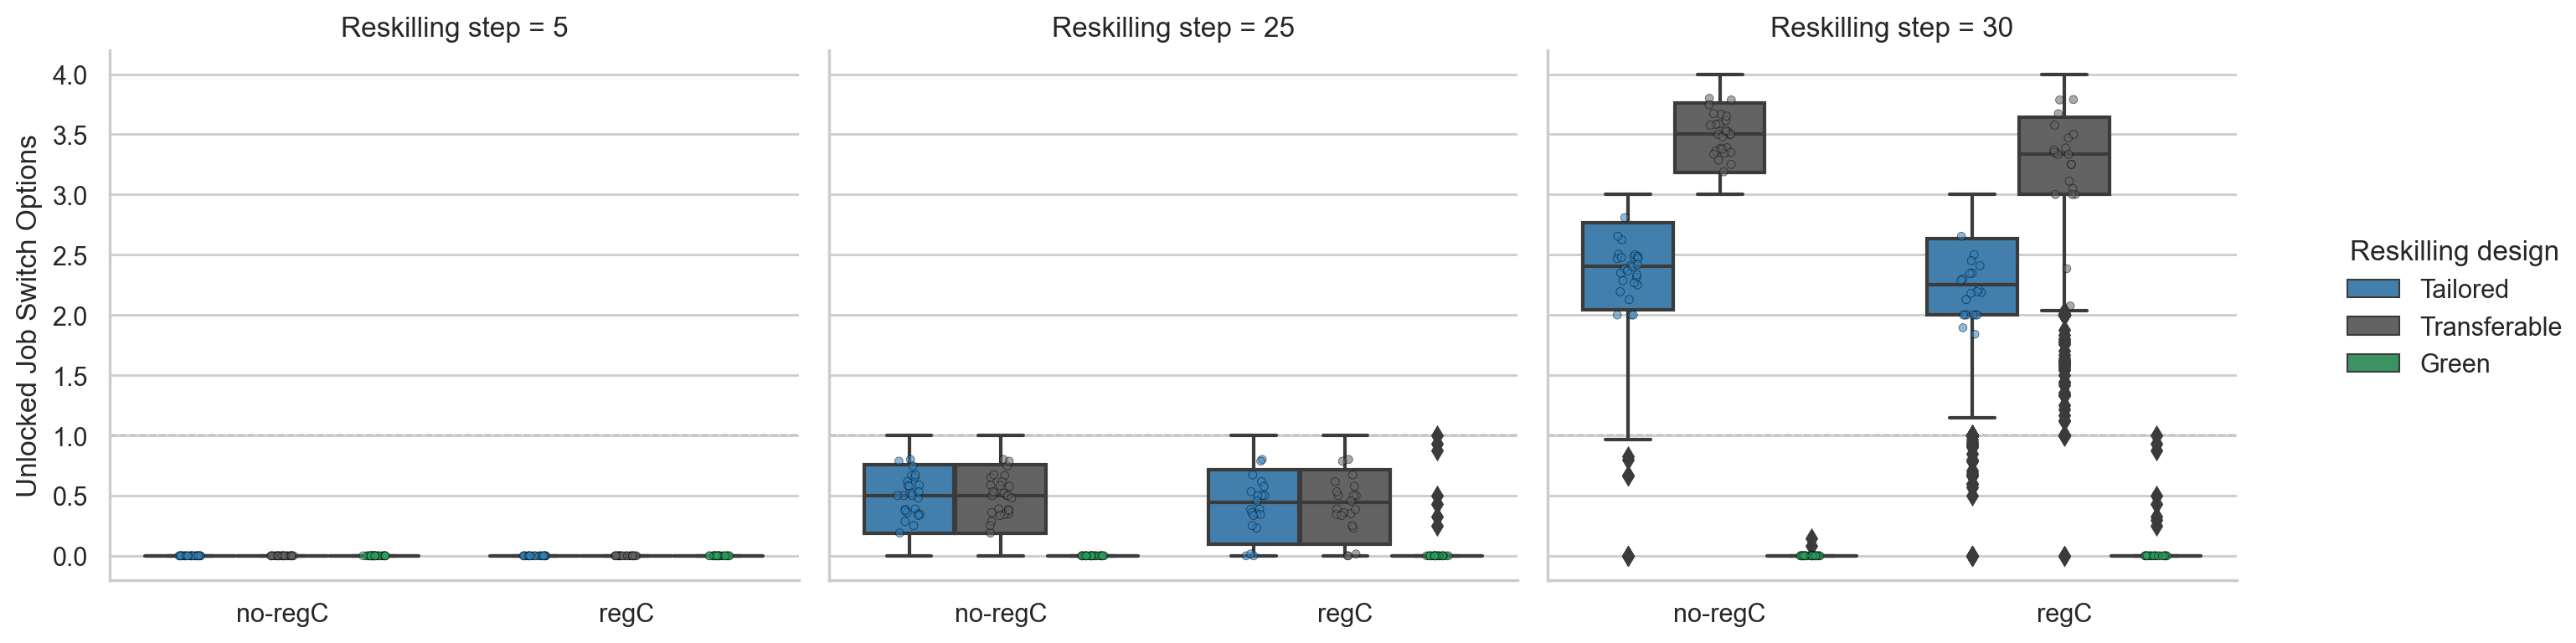

In [22]:
# ==========================================
# Boxplots of unlocked options by regC vs no-regC, per reskilling mode
# Faceted by step (e.g., 1,3,5); at_risk by default
# ==========================================
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# ---- config
SCENARIO = "shortage"        # or "shortage"
STEPS    = [5, 25, 30]        # choose key steps to display
ORDER_X  = ["no-regC", "regC"]

# display labels for modes (same mapping you used before)
label_map = {
    "reskill-optimal":    "Tailored",
    "reskill-coreWeight": "Transferable",
    "reskill-coreRanked": "Transferable",
    "reskill-green":    "Green" # shortage: "reskill-green":      "Green",
}

# palette (blue / green / grey family)
palette_dict_base = {
    "Tailored":     "#3182bd",  # blue
    "Transferable": "#636363",  # grey
    "Green":      "#2ca25f",  # green , shortage: "Green"
}

# scenario aliases
ALIASES = {"at_risk": {"AR", "at_risk"}, "shortage": {"SH", "shortage"}}

# ---- build data slice from long transitions
need_cols = [
    "COUNTRYW","NUTS_ID","regional_constraint","job_pool","reskilling_mode",
    "reskilling_step","n_transitions"
]
data = df_tidy_long_transitions.loc[
    (df_tidy_long_transitions["job_pool"].isin(ALIASES[SCENARIO])) &
    (df_tidy_long_transitions["reskilling_step"].isin(STEPS)),
    [c for c in need_cols if c in df_tidy_long_transitions.columns]
].copy()

# check
data["regional_constraint"] = pd.Categorical(
    data["regional_constraint"], categories=["no-regC","regC"], ordered=True
)

present = data["regional_constraint"].dropna().unique().tolist()
assert any(x in present for x in ["no-regC","regC"]), "No regC/no-regC rows found. Did the tidy rebuild finish?"

# clean numerics
data["reskilling_step"] = pd.to_numeric(data["reskilling_step"], errors="coerce").astype(int)
data["n_transitions"]   = pd.to_numeric(data["n_transitions"], errors="coerce")
data = data.dropna(subset=["n_transitions"])

# map mode labels and restrict to present ones
data["mode_label"] = data["reskilling_mode"].map(label_map)
data = data.dropna(subset=["mode_label"])
hue_order = [m for m in ["Tailored","Transferable","Digital","Green"] if m in data["mode_label"].unique()]
palette_dict = {k: palette_dict_base[k] for k in hue_order}

# nicer facet titles
col_name = "Reskilling step"
data[col_name] = data["reskilling_step"].astype(int)

# ---- country-level medians for overlay dots (avoid overplot clutter)
df_country = (
    data.groupby(["COUNTRYW","regional_constraint","mode_label",col_name], as_index=False)
        ["n_transitions"].median()
)

# ---- plot
sns.set_theme(style="whitegrid")
g = sns.catplot(
    data=data,
    x="regional_constraint", y="n_transitions",
    hue="mode_label",
    col=col_name, col_order=sorted(data[col_name].unique()),
    order=ORDER_X, hue_order=hue_order,
    kind="box",
    dodge=True,
    showfliers=True,  # keep, but small markersize
    height=4, aspect=0.9,
    palette=palette_dict,
)

# style box fliers smaller
for ax in g.axes.flatten():
    for artist in ax.artists:
        pass  # seaborn handles styling; we’ll overlay points next

# overlay country medians as semi-transparent dots
for ax, step in zip(g.axes.flatten(), sorted(data[col_name].unique())):
    sub = df_country[df_country[col_name] == step]
    sns.stripplot(
        data=sub,
        x="regional_constraint", y="n_transitions",
        hue="mode_label",
        order=ORDER_X, hue_order=hue_order,
        dodge=True, size=3.5, linewidth=0.3,
        edgecolor="black", alpha=0.55,
        palette=palette_dict, ax=ax
    )
    # remove the duplicate legend generated by stripplot
    ax.legend_.remove() if ax.get_legend() else None

    # y=1 guide
    ax.axhline(1, linestyle="--", color="black", linewidth=0.8, zorder=0)

    # tidy labels
    ax.set_xlabel("")
    ax.set_ylabel("Unlocked Job Switch Options" if ax is g.axes.flatten()[0] else "")

# legend
try:
    g._legend.remove()
except Exception:
    pass

# add a fresh legend and move it
g.add_legend(title="Reskilling design")
leg = g._legend
if leg is not None:
    leg.set_bbox_to_anchor((1.02, 0.5))  # to the right, centered vertically
    # Matplotlib versions differ: prefer set_location(), else set_loc(), else fallback
    if hasattr(leg, "set_location"):
        leg.set_location("center left")
    elif hasattr(leg, "set_loc"):
        leg.set_loc("center left")
    else:
        leg._loc = 6  # center left (fallback; private attr)
    leg.set_frame_on(False)

# widen right margin so the legend isn't clipped
g.fig.subplots_adjust(right=0.82)

plt.tight_layout()

# ---- save PDF
try:
    out_dir = results_dir
except NameError:
    out_dir = os.path.join(useful_paths.figure_dir, "reskilling_simulation")
os.makedirs(out_dir, exist_ok=True)

scenario_tag = "AR" if SCENARIO=="at_risk" else "SH"
steps_tag = "_".join(map(str, sorted(set(STEPS))))
outfile = os.path.join(out_dir, f"box_transitions_{scenario_tag}_steps_{steps_tag}.pdf")
plt.savefig(outfile, bbox_inches="tight", format="pdf")
print("Saved:", outfile)

/var/folders/1w/t9ryrq_57m77f4wzbw78745m044mx9/T/ipykernel_13751/2422646271.py:77: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  edata.groupby(["COUNTRYW","regional_constraint","mode_label",col_name], as_index=False)[y_col]
/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/categorical.py:253: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/categorical.py:253:

Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/figures/reskilling_simulation/box_earnings_per_worker_SH_steps_5_25_30_3modes.pdf


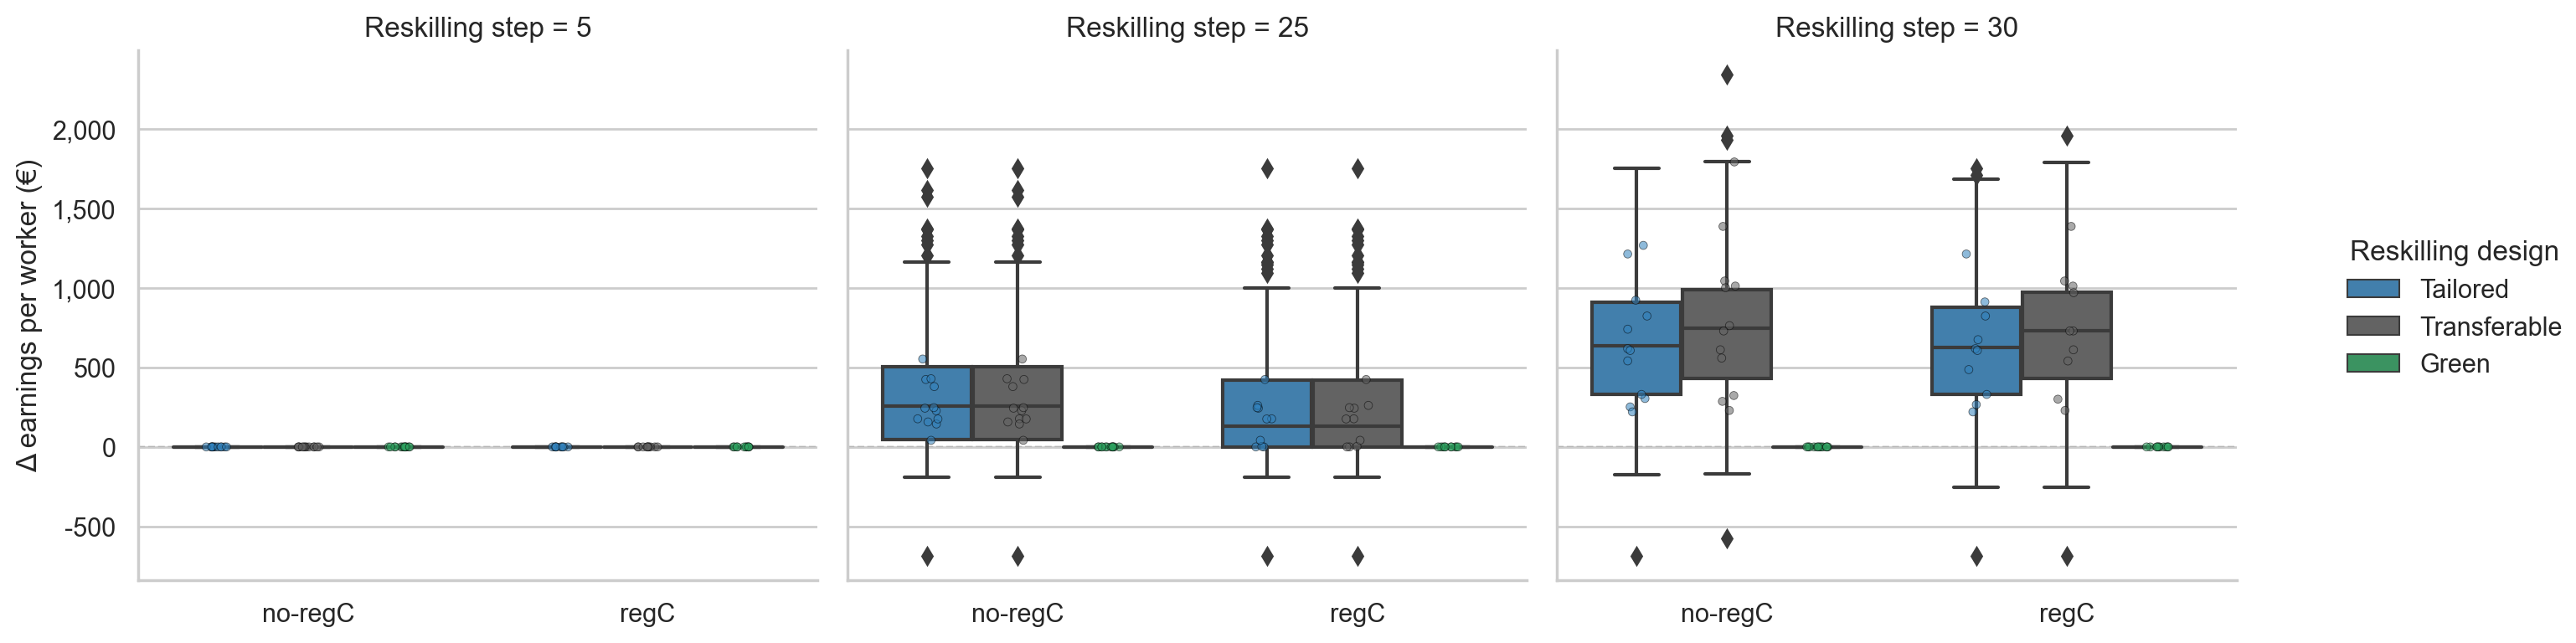

In [23]:
# ==========================================
# Boxplots of Δ earnings per worker (weighted) by regC vs no-regC
# Faceted by step; Tailored vs Transferable vs Digital/Green
# Runs right after your transitions boxplot
# ==========================================
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import os

# ---- config (reuse your choices)
SCENARIO = "shortage"        # or "shortage"
STEPS    = [5, 25, 30] # adapt when shortage/at_risk
ORDER_X  = ["no-regC", "regC"]

# Which three modes to show (Digital for at_risk; Green for shortage)
if SCENARIO == "shortage":
    MODES_WANTED = ["reskill-optimal", "reskill-coreRanked", "reskill-green"]
else:
    MODES_WANTED = ["reskill-optimal", "reskill-coreRanked", "reskill-digital"]

# Display labels & palette
label_map = {
    "reskill-optimal":     "Tailored",
    "reskill-coreRanked":  "Transferable",
    "reskill-coreWeight":  "Transferable",  # alias if present
    "reskill-digital":     "Digital",
    "reskill-green":       "Green",
}
palette_dict_base = {
    "Tailored":     "#3182bd",  # blue
    "Transferable": "#636363",  # grey
    "Digital":      "#2ca25f",  # green
    "Green":        "#2ca25f",  # green (same hue for shortage)
}

ALIASES = {"at_risk": {"AR","at_risk"}, "shortage": {"SH","shortage"}}

# ---- source frame (weighted €/worker preferred)
if "df_tidy_long_earnings_merged" not in globals():
    raise RuntimeError("df_tidy_long_earnings_merged not found. Run the tidy/melt prep first.")
y_candidates = ["earnings_delta_rel_w", "earnings_delta_rel"]  # weighted → fallback unweighted
y_col = next((c for c in y_candidates if c in df_tidy_long_earnings_merged.columns), None)
if y_col is None:
    raise RuntimeError("No per-worker earnings column found (earnings_delta_rel_w / earnings_delta_rel).")

# ---- slice data
need_cols = ["COUNTRYW","regional_constraint","job_pool","reskilling_mode","reskilling_step", y_col]
edata = df_tidy_long_earnings_merged.loc[
    (df_tidy_long_earnings_merged["job_pool"].isin(ALIASES[SCENARIO])) &
    (df_tidy_long_earnings_merged["reskilling_mode"].isin(MODES_WANTED)) &
    (df_tidy_long_earnings_merged["reskilling_step"].isin(STEPS)),
    [c for c in need_cols if c in df_tidy_long_earnings_merged.columns]
].copy()

# enforce x order and clean numerics
edata["regional_constraint"] = pd.Categorical(edata["regional_constraint"],
                                              categories=["no-regC","regC"], ordered=True)
edata["reskilling_step"] = pd.to_numeric(edata["reskilling_step"], errors="coerce").astype(int)
edata[y_col] = pd.to_numeric(edata[y_col], errors="coerce")
edata = edata.dropna(subset=[y_col])

# map display labels & palette (only those present)
edata["mode_label"] = edata["reskilling_mode"].map(label_map)
edata = edata.dropna(subset=["mode_label"])
hue_order = [m for m in ["Tailored","Transferable","Digital","Green"] if m in edata["mode_label"].unique()]
palette_dict = {k: palette_dict_base[k] for k in hue_order}

# facet title
col_name = "Reskilling step"
edata[col_name] = edata["reskilling_step"].astype(int)

# country-level medians for overlay dots
df_country = (
    edata.groupby(["COUNTRYW","regional_constraint","mode_label",col_name], as_index=False)[y_col]
         .median()
)

# ---- plot
sns.set_theme(style="whitegrid")
g = sns.catplot(
    data=edata,
    x="regional_constraint", y=y_col,
    hue="mode_label",
    col=col_name, col_order=sorted(edata[col_name].unique()),
    order=[x for x in ORDER_X if x in edata["regional_constraint"].cat.categories],
    hue_order=hue_order,
    kind="box",
    dodge=True,
    showfliers=True,
    height=4, aspect=0.9,
    palette=palette_dict,
)

# overlay dots = country medians
for ax, step in zip(g.axes.flatten(), sorted(edata[col_name].unique())):
    sub = df_country[df_country[col_name] == step]
    if not sub.empty:
        sns.stripplot(
            data=sub,
            x="regional_constraint", y=y_col,
            hue="mode_label",
            order=[x for x in ORDER_X if x in edata["regional_constraint"].cat.categories],
            hue_order=hue_order,
            dodge=True, size=3.5, linewidth=0.3,
            edgecolor="black", alpha=0.55,
            palette=palette_dict, ax=ax
        )
        if ax.get_legend() is not None:
            ax.get_legend().remove()

    ax.axhline(0, linestyle="--", color="black", linewidth=0.8, zorder=0)
    ax.set_xlabel("")
    ax.set_ylabel("Δ earnings per worker (€)" if ax is g.axes.flatten()[0] else "")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, p: f"{v:,.0f}"))

# legend outside on the right (version-safe)
try:
    g._legend.remove()
except Exception:
    pass
g.add_legend(title="Reskilling design")
leg = g._legend
if leg is not None:
    leg.set_bbox_to_anchor((1.02, 0.5))
    if hasattr(leg, "set_location"):
        leg.set_location("center left")
    elif hasattr(leg, "set_loc"):
        leg.set_loc("center left")
    else:
        leg._loc = 6
    leg.set_frame_on(False)

g.fig.subplots_adjust(right=0.82)
plt.tight_layout()

# ---- save
try:
    out_dir = results_dir
except NameError:
    out_dir = os.path.join(useful_paths.figure_dir, "reskilling_simulation")
os.makedirs(out_dir, exist_ok=True)
scenario_tag = "AR" if SCENARIO=="at_risk" else "SH"
steps_tag   = "_".join(map(str, sorted(set(STEPS))))
mode_tag    = "digital" if SCENARIO=="at_risk" else "green"
outfile = os.path.join(out_dir, f"box_earnings_per_worker_{scenario_tag}_steps_{steps_tag}_3modes.pdf")
plt.savefig(outfile, bbox_inches="tight", format="pdf")
print("Saved:", outfile)


#### 5. Summary tables

In [61]:
# ==============================
# Appendix table: €/worker (median, weighted) and Totals (Mio €) by sector within each country
# Values at each (country×sector)'s first-unlock step (median n_transitions ≥ 1);
# Country summary rows use the country-level first-unlock step.
# ==============================
import numpy as np
import pandas as pd
import re, os

# ---- Settings
MODE = "reskill-optimal"
REGC = "regC"
y_pw  = "earnings_delta_rel_w"   # €/worker (weighted)
y_tot = "earnings_delta_abs"     # totals €
ALIASES = {"at_risk": {"AR","at_risk"}, "shortage": {"SH","shortage"}}

# ---- Scenario detection (for pool filtering)
pools_present = set(df_tidy_long_transitions["job_pool"].astype(str).unique())
scenario = "shortage" if (pools_present & ALIASES["shortage"]) else "at_risk"
POOL_SET = ALIASES[scenario]

# ---- Sector label (same as sector plots)
base_sector_col = "NACE2_1D_label"
sector_source = (
    "NACE2_1D_label_short"
    if "NACE2_1D_label_short" in df_tidy_long_earnings_merged.columns
    else base_sector_col
)

def compact_sector_label(s: str) -> str:
    if sector_source == "NACE2_1D_label_short":
        return str(s)
    s = re.sub(r"\s+", " ", str(s)).strip().replace(" and ", " & ")
    repl = {
        "Activities": "Act.", "Activity": "Act.", "Management": "Mgmt.",
        "Professional": "Prof.", "Scientific": "Sci.", "Technical": "Tech.",
        "Information": "Info.", "Communication": "Comm.",
        "Financial": "Fin.", "Insurance": "Ins.",
        "Administrative": "Admin.", "Support": "Support",
        "Transportation": "Transport", "Storage": "Storage",
        "Sewerage": "Sewer.", "Remediation": "Remed.",
    }
    for k, v in repl.items():
        s = re.sub(rf"\b{k}\b", v, s)
    return s

def euro0(x):
    try: return f"€{x:,.0f}".replace(",", " ")
    except: return "—"

def mio1(x):
    try: return f"{x:,.1f}".replace(",", " ")
    except: return "—"

def col_as_series(df, colname):
    """Return the first occurrence of a duplicated column name as a Series, else None."""
    if colname not in df.columns:
        return None
    sub = df.loc[:, df.columns == colname]
    return sub.iloc[:, 0] if sub.shape[1] else None

def pick_series(df, names):
    """Return the first non-None Series among candidate names."""
    for n in names:
        s = col_as_series(df, n)
        if s is not None:
            return s
    return None

# -----------------------------
# Slice & clean earnings data
# -----------------------------
earn = df_tidy_long_earnings_merged.loc[
    (df_tidy_long_earnings_merged["regional_constraint"] == REGC) &
    (df_tidy_long_earnings_merged["reskilling_mode"]     == MODE),
    :
].copy()

# Drop duplicate-named columns (keep first)
earn = earn.loc[:, ~earn.columns.duplicated()]

need_earn_cols = ["COUNTRYW","NUTS_ID","reskilling_step", y_pw, y_tot]
for c in need_earn_cols:
    if c not in earn.columns:
        raise KeyError(f"Missing '{c}' in earnings frame; check the prep block.")

# Build sector display in earnings (robust)
sec_series_earn = pick_series(earn, [sector_source, base_sector_col])
if sec_series_earn is None:
    raise KeyError(f"Neither '{sector_source}' nor '{base_sector_col}' present in earnings frame.")
if sector_source in earn.columns:
    earn["sector_disp"] = sec_series_earn.astype(str)
else:
    earn["sector_disp"] = sec_series_earn.astype(str).map(compact_sector_label)

earn = earn[["COUNTRYW","NUTS_ID","reskilling_step","sector_disp", y_pw, y_tot]].copy()
for c in ["reskilling_step", y_pw, y_tot]:
    earn[c] = pd.to_numeric(earn[c], errors="coerce")
earn.dropna(subset=["COUNTRYW","reskilling_step"], inplace=True)
earn["reskilling_step"] = earn["reskilling_step"].astype(int)

# Countries & sectors
countries = sorted(earn["COUNTRYW"].dropna().unique().tolist())
sectors   = sorted(earn["sector_disp"].dropna().unique().tolist())

# -----------------------------
# Transitions (for first-unlock)
# -----------------------------
tran = df_tidy_long_transitions.loc[
    (df_tidy_long_transitions["regional_constraint"] == REGC) &
    (df_tidy_long_transitions["reskilling_mode"]     == MODE) &
    (df_tidy_long_transitions["job_pool"].astype(str).isin(POOL_SET)),
    :
].copy()

tran = tran.loc[:, ~tran.columns.duplicated()]  # drop duplicate-named cols

need_tran_cols = ["COUNTRYW","NUTS_ID","reskilling_step","n_transitions"]
for c in need_tran_cols:
    if c not in tran.columns:
        raise KeyError(f"Missing '{c}' in transitions frame.")

# Build sector display in transitions (robust)
sec_series_tran = pick_series(tran, [sector_source, base_sector_col])
if sec_series_tran is None:
    raise KeyError(f"Neither '{sector_source}' nor '{base_sector_col}' present in transitions frame.")
if sector_source in tran.columns:
    tran["sector_disp"] = sec_series_tran.astype(str)
else:
    tran["sector_disp"] = sec_series_tran.astype(str).map(compact_sector_label)

# numeric clean
tran["reskilling_step"] = pd.to_numeric(tran["reskilling_step"], errors="coerce").astype("Int64")
tran["n_transitions"]   = pd.to_numeric(tran["n_transitions"],   errors="coerce")
tran.dropna(subset=["COUNTRYW","reskilling_step","n_transitions","sector_disp"], inplace=True)
tran["reskilling_step"] = tran["reskilling_step"].astype(int)
tran = tran[tran["COUNTRYW"].isin(countries)].copy()

# median transitions per (country, sector, step)
med_tran_cs = (
    tran.groupby(["COUNTRYW","sector_disp","reskilling_step"])["n_transitions"]
        .median().reset_index()
)
# median transitions per (country, step)
med_tran_c = (
    tran.groupby(["COUNTRYW","reskilling_step"])["n_transitions"]
        .median().reset_index()
)

def first_unlock_step(steps, vals):
    steps = np.asarray(steps); vals = np.asarray(vals)
    idx = np.where(vals >= 1)[0]
    return int(steps[idx[0]]) if idx.size else None

# Lookups
first_unlock_cs = {}
for (cty, sec), sub in med_tran_cs.groupby(["COUNTRYW","sector_disp"]):
    st = first_unlock_step(sub["reskilling_step"].values, sub["n_transitions"].values)
    if st is not None:
        first_unlock_cs[(cty, sec)] = st

first_unlock_c = {}
for cty, sub in med_tran_c.groupby("COUNTRYW"):
    st = first_unlock_step(sub["reskilling_step"].values, sub["n_transitions"].values)
    if st is not None:
        first_unlock_c[cty] = st

# -----------------------------
# Aggregate earnings at needed steps
# -----------------------------
med_earn_cs = (
    earn.groupby(["COUNTRYW","sector_disp","reskilling_step"])[y_pw]
        .median().reset_index()
)
med_earn_c = (
    earn.groupby(["COUNTRYW","reskilling_step"])[y_pw]
        .median().reset_index()
)
sum_tot_c = (
    earn.groupby(["COUNTRYW","reskilling_step"])[y_tot]
        .sum().reset_index()
)

# -----------------------------
# Build output matrix
# -----------------------------
row_labels = sectors + ["Country avg (€/worker)", "Country total (Mio €)"]
out = pd.DataFrame(index=row_labels, columns=countries, dtype=object)

for cty in countries:
    step_c = first_unlock_c.get(cty, None)

    # sector rows (each at its own first unlock)
    for sec in sectors:
        step_cs = first_unlock_cs.get((cty, sec), None)
        if step_cs is None:
            out.loc[sec, cty] = "—"
            continue
        sub = med_earn_cs[
            (med_earn_cs["COUNTRYW"]==cty) &
            (med_earn_cs["sector_disp"]==sec) &
            (med_earn_cs["reskilling_step"]==step_cs)
        ]
        out.loc[sec, cty] = (
            f"{euro0(float(sub[y_pw].iloc[0]))} (step {step_cs})" if len(sub) else "—"
        )

    # country avg €/worker at country-level step
    if step_c is not None:
        subc = med_earn_c[(med_earn_c["COUNTRYW"]==cty) & (med_earn_c["reskilling_step"]==step_c)]
        out.loc["Country avg (€/worker)", cty] = (
            f"{euro0(float(subc[y_pw].iloc[0]))} (step {step_c})" if len(subc) else "—"
        )
    else:
        out.loc["Country avg (€/worker)", cty] = "—"

    # country total (Mio €) at country-level step
    if step_c is not None:
        subt = sum_tot_c[(sum_tot_c["COUNTRYW"]==cty) & (sum_tot_c["reskilling_step"]==step_c)]
        out.loc["Country total (Mio €)", cty] = (
            f"{mio1(float(subt[y_tot].iloc[0]) / 1e6)} (step {step_c})" if len(subt) else "—"
        )
    else:
        out.loc["Country total (Mio €)", cty] = "—"

print(f"Scenario: {scenario} | Countries: {len(countries)} | Sectors: {len(sectors)}")
display(out)

# Save to disk
out_dir = os.path.join(results_dir)
os.makedirs(out_dir, exist_ok=True)
csv_path  = os.path.join(out_dir, f"{scenario}_appendix_country_by_sector_first_unlock.csv")
xlsx_path = os.path.join(out_dir, f"{scenario}_appendix_country_by_sector_first_unlock.xlsx")
out.to_csv(csv_path, encoding="utf-8-sig")
with pd.ExcelWriter(xlsx_path, engine="xlsxwriter") as xw:
    out.to_excel(xw, sheet_name="Table", index=True)
print("Saved:", csv_path)
print("Saved:", xlsx_path)

Scenario: at_risk | Countries: 21 | Sectors: 8


,AT,BE,CH,CZ,DE,DK,EL,ES,FI,FR,HR,HU,IE,IT,LT,NO,PL,PT,RO,SE,SK
"Agriculture, Forestry and Fishing",€nan (step 4),€nan (step 14),€-1 754 (step 0),€nan (step 8),€nan (step 4),€-537 (step 13),€61 (step 4),€nan (step 10),€856 (step 14),€-965 (step 7),€nan (step 5),€nan (step 8),€-570 (step 4),€nan (step 10),€nan (step 7),€-680 (step 6),€nan (step 14),€-417 (step 11),€nan (step 5),€343 (step 14),€-333 (step 8)
Construction,€nan (step 4),€nan (step 4),€-359 (step 4),€nan (step 4),€nan (step 4),€-410 (step 4),€56 (step 4),€nan (step 4),€-97 (step 4),€-217 (step 4),€nan (step 4),€nan (step 4),€-15 (step 4),€nan (step 4),€nan (step 4),€-334 (step 4),€nan (step 4),€-119 (step 4),€nan (step 4),€-333 (step 4),€-9 (step 4)
"Electricity, Gas, Steam and Air Conditioning Supply",€nan (step 4),€nan (step 4),€-957 (step 4),€nan (step 4),€nan (step 4),€-1 594 (step 0),€-41 (step 4),€nan (step 4),€-1 370 (step 0),€-332 (step 4),€nan (step 4),€nan (step 4),€-698 (step 0),€nan (step 4),€nan (step 0),€-2 207 (step 0),€nan (step 4),€-346 (step 4),€nan (step 4),€-1 451 (step 0),€-185 (step 4)
Manufacturing,€nan (step 0),€nan (step 4),€-1 580 (step 3),€nan (step 3),€nan (step 4),€-1 341 (step 0),€-90 (step 6),€nan (step 4),€-998 (step 0),€-421 (step 4),€nan (step 3),€nan (step 3),€-925 (step 4),€nan (step 3),€nan (step 3),€-781 (step 4),€nan (step 0),€-179 (step 6),€nan (step 3),€-869 (step 3),€-297 (step 3)
Mining and Quarrying,€nan (step 4),€nan (step 0),€-1 714 (step 13),€nan (step 4),€nan (step 4),€-1 394 (step 0),€-131 (step 5),€nan (step 4),€-1 101 (step 4),€-1 027 (step 4),€nan (step 6),€nan (step 4),€132 (step 6),€nan (step 4),€nan (step 4),€-1 322 (step 4),€nan (step 4),€-87 (step 4),€nan (step 4),€-482 (step 5),€-72 (step 4)
Transportation and Storage,€nan (step 7),€nan (step 8),€-1 556 (step 10),€nan (step 8),€nan (step 9),€-1 531 (step 10),€-242 (step 13),€nan (step 10),€-927 (step 5),€-542 (step 7),€nan (step 7),€nan (step 5),€-541 (step 7),€nan (step 9),€nan (step 4),€-1 338 (step 8),€nan (step 8),€-474 (step 8),€nan (step 5),€-1 166 (step 10),€-257 (step 7)
"Water Supply; Sewerage, Waste Management and Remediation Activities",€nan (step 4),€nan (step 4),€-551 (step 4),€nan (step 4),€nan (step 4),€-1 160 (step 4),€-57 (step 0),€nan (step 4),€-216 (step 4),€-9 (step 4),€nan (step 4),€nan (step 5),€-410 (step 4),€nan (step 4),€nan (step 4),€-1 417 (step 7),€nan (step 4),€-178 (step 4),€nan (step 0),€-265 (step 4),€-54 (step 4)
Wholesale and Retail Trade; Repair of Motor Vehicles and Motorcycles,€nan (step 4),€nan (step 5),€-659 (step 5),€nan (step 5),€nan (step 5),€-647 (step 5),€-4 (step 5),€nan (step 5),€-101 (step 4),€-302 (step 5),€nan (step 5),€nan (step 4),€-109 (step 8),€nan (step 4),€nan (step 4),€-860 (step 5),€nan (step 5),€-194 (step 6),€nan (step 4),€-307 (step 5),€-146 (step 5)
Country avg (€/worker),€nan (step 4),€nan (step 4),€-799 (step 4),€nan (step 4),€nan (step 4),€-959 (step 4),€-89 (step 5),€nan (step 4),€-453 (step 4),€-425 (step 4),€nan (step 4),€nan (step 4),€-642 (step 4),€nan (step 4),€nan (step 4),€-1 036 (step 4),€nan (step 4),€-269 (step 5),€nan (step 4),€-369 (step 4),€-162 (step 4)
Country total (Mio €),0.0 (step 4),0.0 (step 4),-481.2 (step 4),0.0 (step 4),0.0 (step 4),-351.5 (step 4),-60.8 (step 5),0.0 (step 4),-119.3 (step 4),-1 986.3 (step 4),0.0 (step 4),0.0 (step 4),-350.4 (step 4),0.0 (step 4),0.0 (step 4),-516.7 (step 4),0.0 (step 4),-89.3 (step 5),0.0 (step 4),-336.6 (step 4),-100.3 (step 4)


ModuleNotFoundError: No module named 'xlsxwriter'

In [64]:
# ==========================================================
# Appendix Table: Income change (€/worker + Mio € totals)
# by country and sector at first-unlock step — robust y_pw
# ==========================================================

import numpy as np
import pandas as pd
import os

# ---- Config ----
MODE = "reskill-optimal"
REG  = "regC"

# Automatically detect scenario (same logic as plots)
ALIASES = {"at_risk": {"AR", "at_risk"}, "shortage": {"SH", "shortage"}}
pools_present = set(df_tidy_long_earnings_merged["job_pool"].unique())
scenario = "shortage" if (pools_present & ALIASES["shortage"]) else "at_risk"

# Countries without earnings (you provided these)
iso_missing_earnings = ['IT','NL','DE','HU','AT','RO','PL','ES','LT','CY','BE','CZ','HR','IS','LV']
countries_with_data = sorted(
    [c for c in df_tidy_long_earnings_merged["COUNTRYW"].unique() if c not in iso_missing_earnings]
)

# ---- Compact sector labels ----
compact_map = {
    "Agriculture, Forestry and Fishing": "Agri., Forest., Fish.",
    "Mining and Quarrying": "Mining",
    "Manufacturing": "Manufacturing",
    "Electricity, Gas, Steam and Air Conditioning Supply": "Electricity, Gas",
    "Water Supply; Sewerage, Waste Management and Remediation Activities": "Water, Waste Mgmt.",
    "Construction": "Construction",
    "Wholesale and Retail Trade; Repair of Motor Vehicles and Motorcycles": "Trade, Repair",
    "Transportation and Storage": "Transport",
    "Information and Communication": "Info. & Comm.",
    "Financial and Insurance Activities": "Finance & Insurance",
    "Professional, Scientific and Technical Activities": "Prof., Sci., Tech.",
    "Administrative and Support Service Activities": "Admin. & Support",
}
def compact_sector_label(s): return compact_map.get(s, s)

# ---- Helper for duplicate columns ----
def col_as_series(df, colname):
    """Return the first column as a Series if duplicated names exist; None if absent."""
    if colname not in df.columns:
        return None
    sub = df.loc[:, df.columns == colname]
    if sub.shape[1] == 0:
        return None
    return sub.iloc[:, 0]

# ==========================================================
# 1) Prepare earnings and transitions frames
# ==========================================================
earn = df_tidy_long_earnings_merged.copy()
tran = df_tidy_long_transitions.copy()

# Remove duplicate-named columns
earn = earn.loc[:, ~earn.columns.duplicated()]
tran = tran.loc[:, ~tran.columns.duplicated()]

# Keep only relevant constraint & mode
earn = earn.loc[
    (earn["reskilling_mode"] == MODE) &
    (earn["regional_constraint"] == REG)
].copy()
tran = tran.loc[
    (tran["reskilling_mode"] == MODE) &
    (tran["regional_constraint"] == REG)
].copy()

# ---- Decide €/worker column (y_pw) robustly
y_tot = "earnings_delta_abs"

if "earnings_delta_rel_w" in earn.columns:
    y_pw = "earnings_delta_rel_w"
elif "earnings_delta_rel" in earn.columns:
    y_pw = "earnings_delta_rel"  # unweighted fallback
elif ("earnings_delta_abs" in earn.columns) and ("weight_sum" in earn.columns):
    earn["earnings_delta_rel_w"] = earn["earnings_delta_abs"] / earn["weight_sum"]
    earn.loc[earn["weight_sum"] == 0, "earnings_delta_rel_w"] = np.nan
    y_pw = "earnings_delta_rel_w"
else:
    raise KeyError(
        "No per-worker earnings column available. Need 'earnings_delta_rel_w' or "
        "'earnings_delta_rel' or both 'earnings_delta_abs' and 'weight_sum' to compute it."
    )

# Sanity checks
for c in ["COUNTRYW","reskilling_step", y_tot, y_pw]:
    if c not in earn.columns:
        raise KeyError(f"Missing '{c}' in earnings frame.")

# Sector label (prefer short if present) — NO 'or' on Series
sector_col_short = "NACE2_1D_label_short"
sector_col_base  = "NACE2_1D_label"
sec_series_earn = col_as_series(earn, sector_col_short)
if sec_series_earn is None:
    sec_series_earn = col_as_series(earn, sector_col_base)
if sec_series_earn is None:
    raise KeyError("No sector label column found in earnings frame.")
earn["sector_disp"] = sec_series_earn.astype(str).map(compact_sector_label)

# Ensure transitions has sector too (use base/short if present) — NO 'or' on Series
sec_series_tran = col_as_series(tran, sector_col_short)
if sec_series_tran is None:
    sec_series_tran = col_as_series(tran, sector_col_base)
if sec_series_tran is None:
    tran["sector_disp"] = "All sectors"  # rare fallback
else:
    tran["sector_disp"] = sec_series_tran.astype(str).map(compact_sector_label)

# ---- Clean numeric
for df_ in [earn, tran]:
    df_["reskilling_step"] = pd.to_numeric(df_["reskilling_step"], errors="coerce").astype("Int64")
earn[y_pw]  = pd.to_numeric(earn[y_pw],  errors="coerce")
earn[y_tot] = pd.to_numeric(earn[y_tot], errors="coerce")
tran["n_transitions"] = pd.to_numeric(tran["n_transitions"], errors="coerce")

# Keep only countries that have earnings data
earn = earn[earn["COUNTRYW"].isin(countries_with_data)].copy()
tran = tran[tran["COUNTRYW"].isin(countries_with_data)].copy()

# ==========================================================
# 2) Compute first unlock steps (median n_transitions ≥ 1)
# ==========================================================
def first_unlock_step(group):
    s = group.groupby("reskilling_step")["n_transitions"].median().sort_index()
    ge1 = np.where(s.values >= 1)[0]
    return (int(s.index[ge1[0]]) if len(ge1) else np.nan)

first_unlock_cs = (
    tran.groupby(["COUNTRYW", "sector_disp"], dropna=False)
        .apply(first_unlock_step)
        .reset_index(name="first_unlock_step")
)

first_unlock_c = (
    tran.groupby(["COUNTRYW"], dropna=False)
        .apply(first_unlock_step)
        .reset_index(name="first_unlock_step")
)

# ==========================================================
# 3) Median €/worker + total Mio € at those steps
# ==========================================================
med_earn_cs = (
    earn.groupby(["COUNTRYW", "sector_disp", "reskilling_step"], dropna=False)[y_pw]
        .median().reset_index()
)
sum_tot_c = (
    earn.groupby(["COUNTRYW", "reskilling_step"], dropna=False)[y_tot]
        .sum().reset_index()
)

# ==========================================================
# 4) Assemble the wide table
# ==========================================================
sectors_list = sorted(earn["sector_disp"].dropna().unique())
out = pd.DataFrame()

for country in countries_with_data:
    col_vals = {}
    # per-sector rows
    for sector in sectors_list:
        step = first_unlock_cs.loc[
            (first_unlock_cs["COUNTRYW"] == country) &
            (first_unlock_cs["sector_disp"] == sector),
            "first_unlock_step"
        ]
        if step.empty or not np.isfinite(step.iloc[0]):
            val_txt = "—"
        else:
            st = int(step.iloc[0])
            val = med_earn_cs.loc[
                (med_earn_cs["COUNTRYW"] == country) &
                (med_earn_cs["sector_disp"] == sector) &
                (med_earn_cs["reskilling_step"] == st),
                y_pw
            ]
            val_txt = (
                f"€{val.iloc[0]:,.0f}".replace(",", " ") + f" (step {st})"
                if len(val) and np.isfinite(val.iloc[0]) else "—"
            )
        col_vals[sector] = val_txt

    # Country avg and total (at country unlock step)
    step_c = first_unlock_c.loc[first_unlock_c["COUNTRYW"] == country, "first_unlock_step"]
    if step_c.empty or not np.isfinite(step_c.iloc[0]):
        avg_txt = tot_txt = "—"
    else:
        stc = int(step_c.iloc[0])
        # country avg €/worker = median across (NUTS×sector) at that step
        val_avg = earn.loc[
            (earn["COUNTRYW"] == country) &
            (earn["reskilling_step"] == stc),
            y_pw
        ]
        # country total Mio €
        val_tot = sum_tot_c.loc[
            (sum_tot_c["COUNTRYW"] == country) &
            (sum_tot_c["reskilling_step"] == stc),
            y_tot
        ]
        avg_txt = (
            f"€{val_avg.median():,.0f}".replace(",", " ") + f" (step {stc})"
            if len(val_avg) and np.isfinite(val_avg.median()) else "—"
        )
        tot_txt = (
            f"{(val_tot.sum()/1e6):,.1f}".replace(",", " ") + f" (step {stc})"
            if len(val_tot) and np.isfinite(val_tot.sum()) else "—"
        )

    col_vals["Country avg (€/worker)"] = avg_txt
    col_vals["Country total (Mio €)"]  = tot_txt

    out[country] = pd.Series(col_vals)

# Ensure row order: sectors, then summaries
out = out.reindex(sectors_list + ["Country avg (€/worker)", "Country total (Mio €)"])

# ==========================================================
# 5) Order countries by total loss (most negative first)
# ==========================================================
order_vals = []
for c in out.columns:
    val = out.at["Country total (Mio €)", c]
    try:
        num = float(val.split(" ")[0].replace(" ","").replace(",", ""))
    except Exception:
        num = 0.0
    order_vals.append((c, num))
order_sorted = [c for c,_ in sorted(order_vals, key=lambda x: x[1])]
out = out.loc[:, order_sorted]

# ==========================================================
# 6) Display + Save
# ==========================================================
pd.options.display.max_rows = 30
pd.options.display.max_colwidth = 40
display(out.style.set_caption(f"Income change at first unlocked job transition — scenario={scenario}, mode={MODE}, regC"))

out_dir = os.path.join(results_dir, "appendix_tables")
os.makedirs(out_dir, exist_ok=True)
csv_path  = os.path.join(out_dir, f"{scenario}_appendix_table_regC.csv")
xlsx_path = os.path.join(out_dir, f"{scenario}_appendix_table_regC.xlsx")
out.to_csv(csv_path, encoding="utf-8-sig")
with pd.ExcelWriter(xlsx_path, engine="xlsxwriter") as xw:
    out.to_excel(xw, sheet_name="Table", index=True)
    ws = xw.sheets["Table"]
    ws.freeze_panes(1, 1)
    for i, col in enumerate([""] + out.columns.tolist()):
        width = 18 if i == 0 else 15
        ws.set_column(i, i, width)
print("Saved:", csv_path)
print("Saved:", xlsx_path)

/var/folders/1w/t9ryrq_57m77f4wzbw78745m044mx9/T/ipykernel_267/3857348223.py:134: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(first_unlock_step)
/var/folders/1w/t9ryrq_57m77f4wzbw78745m044mx9/T/ipykernel_267/3857348223.py:140: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(first_unlock_step)


,FR,NO,CH,DK,IE,SE,FI,SK,PT,EL,EE,LU
"Agri., Forest., Fish.",€-965 (step 7),€-680 (step 6),€-1 754 (step 0),€-537 (step 13),€-570 (step 4),€343 (step 14),€856 (step 14),€-333 (step 8),€-417 (step 11),€61 (step 4),—,—
Construction,€-217 (step 4),€-334 (step 4),€-359 (step 4),€-410 (step 4),€-15 (step 4),€-333 (step 4),€-97 (step 4),€-9 (step 4),€-119 (step 4),€56 (step 4),—,—
"Electricity, Gas",€-332 (step 4),€-2 207 (step 0),€-957 (step 4),€-1 594 (step 0),€-698 (step 0),€-1 451 (step 0),€-1 370 (step 0),€-185 (step 4),€-346 (step 4),€-41 (step 4),—,—
Manufacturing,€-421 (step 4),€-781 (step 4),€-1 580 (step 3),€-1 341 (step 0),€-925 (step 4),€-869 (step 3),€-998 (step 0),€-297 (step 3),€-179 (step 6),€-90 (step 6),—,—
Mining,€-1 027 (step 4),€-1 322 (step 4),€-1 714 (step 13),€-1 394 (step 0),€132 (step 6),€-482 (step 5),€-1 101 (step 4),€-72 (step 4),€-87 (step 4),€-131 (step 5),—,—
"Trade, Repair",€-302 (step 5),€-860 (step 5),€-659 (step 5),€-647 (step 5),€-109 (step 8),€-307 (step 5),€-101 (step 4),€-146 (step 5),€-194 (step 6),€-4 (step 5),—,—
Transport,€-542 (step 7),€-1 338 (step 8),€-1 556 (step 10),€-1 531 (step 10),€-541 (step 7),€-1 166 (step 10),€-927 (step 5),€-257 (step 7),€-474 (step 8),€-242 (step 13),—,—
"Water, Waste Mgmt.",€-9 (step 4),€-1 417 (step 7),€-551 (step 4),€-1 160 (step 4),€-410 (step 4),€-265 (step 4),€-216 (step 4),€-54 (step 4),€-178 (step 4),€-57 (step 0),—,—
Country avg (€/worker),€-425 (step 4),€-1 036 (step 4),€-799 (step 4),€-959 (step 4),€-642 (step 4),€-369 (step 4),€-453 (step 4),€-162 (step 4),€-269 (step 5),€-89 (step 5),—,—
Country total (Mio €),-1 986.3 (step 4),-516.7 (step 4),-481.2 (step 4),-351.5 (step 4),-350.4 (step 4),-336.6 (step 4),-119.3 (step 4),-100.3 (step 4),-89.3 (step 5),-60.8 (step 5),—,—


ModuleNotFoundError: No module named 'xlsxwriter'

#### (6. KDE plots)


In [108]:
# ==========================================
# Appendix: 2D KDE of (step, unlocked options)
# Facet by reskilling design; rows by regional_constraint if both present
# ==========================================
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os, re

# ---- detect scenario & step extent
ALIASES = {"at_risk": {"AR","at_risk"}, "shortage": {"SH","shortage"}}
pools_present = set(df_tidy_long_transitions["job_pool"].astype(str).unique())
SCENARIO = "shortage" if (pools_present & ALIASES["shortage"]) else "at_risk"
X_TARGET_MAX = 30 if SCENARIO == "shortage" else 20

# ---- filter base: scenario + available constraints
pool_filter = df_tidy_long_transitions["job_pool"].astype(str).isin(ALIASES[SCENARIO])
base = df_tidy_long_transitions.loc[pool_filter].copy()

# Which modes to show (Digital for at_risk; Green for shortage)
modes_wanted = ["reskill-optimal", "reskill-coreRanked",
                ("reskill-green" if SCENARIO == "shortage" else "reskill-digital")]
present_modes = set(base["reskilling_mode"].astype(str).unique())
modes_to_plot = [m for m in modes_wanted if m in present_modes]
if not modes_to_plot:
    raise ValueError(f"No expected reskilling modes found. Saw: {sorted(present_modes)}")

# Display labels & palette consistent with other figs
label_map = {
    "reskill-optimal":    "Tailored",
    "reskill-coreRanked": "Transferable",
    "reskill-coreWeight": "Transferable",  # alias if older files
    "reskill-digital":    "Digital",
    "reskill-green":      "Green",
}
palette_map = {
    "Tailored":     "#3182bd",  # blue
    "Transferable": "#636363",  # grey
    "Digital":      "#2ca25f",  # green
    "Green":        "#2ca25f",  # green
}

df = base.loc[base["reskilling_mode"].isin(modes_to_plot)].copy()
df["mode_label"] = df["reskilling_mode"].map(label_map)

# numeric cleaning + tiny jitter on integer step to help KDE
df["reskilling_step"] = pd.to_numeric(df["reskilling_step"], errors="coerce")
df["n_transitions"]   = pd.to_numeric(df["n_transitions"],   errors="coerce")
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["reskilling_step","n_transitions"])

rng = np.random.default_rng(42)
df["step_jit"] = df["reskilling_step"] + rng.uniform(-0.15, 0.15, len(df))  # modest jitter

# axis ranges (shared across facets)
xmax = max(int(df["reskilling_step"].max()), X_TARGET_MAX)
lo, hi = df["n_transitions"].quantile([0.01, 0.99])
pad = 0.10 * max(1.0, abs(lo), abs(hi))
ymin, ymax = max(0.0, lo - pad), hi + pad

# constraints present?
present_constraints = df["regional_constraint"].dropna().astype(str).unique().tolist()
row_facet = "regional_constraint" if {"regC","no-regC"} & set(present_constraints) else None

# order columns by your design order
col_order = [label_map[m] for m in modes_to_plot]

# ---- build FacetGrid
facet_kws = dict(sharex=True, sharey=True, height=3.8, aspect=1.1)
if row_facet:
    g = sns.FacetGrid(df, row=row_facet, col="mode_label",
                      row_order=[x for x in ["no-regC","regC"] if x in present_constraints],
                      col_order=col_order, **facet_kws)
else:
    g = sns.FacetGrid(df, col="mode_label", col_order=col_order, **facet_kws)

# First pass (placeholder) so we can style per-axes
g.map_dataframe(sns.kdeplot, x="step_jit", y="n_transitions",
                fill=True, levels=8, thresh=0.03, bw_adjust=0.8, color="lightgrey")

# ---- style each facet with its own color and axes cosmetics
axes = g.axes.flat if hasattr(g.axes, "flat") else np.array([g.ax])
for ax in axes:
    # identify the facet's mode label from its title
    title = ax.get_title()
    # seaborn titles like: "mode_label = Tailored" or "regional_constraint = regC | mode_label = Tailored"
    m = re.search(r"mode_label\s*=\s*([^\|]+)$", title)
    label = m.group(1).strip() if m else col_order[0]
    color = palette_map.get(label, "#4c4c4c")

    # clear the generic collections and redraw with the right color
    ax.collections.clear()
    if row_facet:
        # get the row's constraint
        r = re.search(r"regional_constraint\s*=\s*([^\|]+)", title)
        rc = r.group(1).strip() if r else None
        sub = df[(df["mode_label"]==label) & ((df["regional_constraint"]==rc) if rc else True)]
    else:
        sub = df[df["mode_label"]==label]

    sns.kdeplot(
        data=sub,
        x="step_jit", y="n_transitions",
        fill=True, levels=8, thresh=0.03, bw_adjust=0.8,
        color=color, ax=ax
    )

    # panel styling to match your look
    ax.set_facecolor("white")
    ax.grid(True, which="major", axis="both", linewidth=0.8, color="0.92")
    ax.grid(True, which="minor", axis="both", linewidth=0.5, color="0.95")
    ax.axhline(1, linestyle="--", color="black", linewidth=0.7, zorder=0)

    ax.set_xlim(-0.5, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_xticks(np.arange(0, xmax + 1, 5), minor=False)
    ax.set_xticks(np.arange(0, xmax + 1, 1), minor=True)
    ax.set_yticks(np.arange(0, int(np.ceil(ymax)) + 1, 2), minor=False)
    ax.set_yticks(np.arange(0, int(np.ceil(ymax)) + 1, 1), minor=True)

    ax.set_xlabel("Reskilling step")
    ax.set_ylabel("Unlocked Job Switch Options")

# tidy titles
if row_facet:
    for ax in axes:
        ax.set_title(re.sub(r"^.*\|\s*mode_label\s*=\s*", "", ax.get_title()))
else:
    for ax in axes:
        ax.set_title(ax.get_title().replace("mode_label = ", ""))

sns.despine()
g.figure.subplots_adjust(top=0.86)
rc_text = "regC + no-regC" if row_facet else "regC only" if "regC" in present_constraints else "no-regC"
g.figure.suptitle(f"2D density of (step, unlocked options) — {SCENARIO.upper()}, {rc_text}", y=0.98)

# ---- save PDF
try:
    out_dir = results_dir
except NameError:
    out_dir = os.path.join(useful_paths.figure_dir, "reskilling_simulation")
os.makedirs(out_dir, exist_ok=True)
fname = f"{SCENARIO}_kde_transitions_by_mode_{'both' if row_facet else rc_text.replace(' ','_')}.pdf"
g.figure.savefig(os.path.join(out_dir, fname), bbox_inches="tight", format="pdf")
plt.close(g.figure)
print("Saved:", os.path.join(out_dir, fname))

/var/folders/1w/t9ryrq_57m77f4wzbw78745m044mx9/T/ipykernel_46555/3094953256.py:50: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["reskilling_step","n_transitions"])
/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/_core.py:1054: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_null', True):
/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/_core.py:1054: FutureWarning: use_inf_as_na option is depreca

Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/figures/reskilling_simulation/at_risk_kde_transitions_by_mode_both.pdf
